In [53]:
import mwapi
from mwapi.errors import APIError


def query(category_title):
    pages = []
    session = mwapi.Session(
        'https://en.wikipedia.org',
        user_agent='mwapi sync demo'
    )
    try:
        # Use continuation to fetch all pages in the category
        for portion in session.get(
            formatversion=2,
            action='query',
            generator='categorymembers',
            gcmtitle=category_title,
            gcmlimit=100,  # 100 results per request
            continuation=True
        ):
            if 'query' in portion and 'pages' in portion['query']:
                for page in portion['query']['pages']:
                    pages.append(page['title'])
            else:
                print("MediaWiki returned empty result batch.")
    except APIError as error:
        raise ValueError(
            "MediaWiki returned an error:", str(error)
        )
    print("Fetched {} pages".format(len(pages)))
    return pages

In [58]:
def get_leaf_pages(category_title, seen=None):
    """
    Recursively fetch leaf pages (articles) in a category hierarchy.
    Leaf pages are those that are not themselves categories.
    """
    if seen is None:
        seen = set()
    leaf_pages = []
    page_titles = query(category_title)
    for title in page_titles:
        if title.startswith('Category:'):
            cat_title = title
            if cat_title not in seen:
                seen.add(cat_title)
                leaf_pages.extend(get_leaf_pages(cat_title, seen))
        else:
            leaf_pages.append(title)
    return leaf_pages

def get_leaf_pages_ethnicity(category_title, filter_, seen=None):
    """
    Recursively fetch leaf pages (articles) in a category hierarchy.
    Leaf pages are those that are not themselves categories.
    """
    if seen is None:
        seen = set()
    leaf_pages = []
    page_titles = query(category_title)
    for title in page_titles:
        if title.startswith('Category:'):
            cat_title = title
            if cat_title not in seen and filter_ in cat_title.lower():
                seen.add(cat_title)
                leaf_pages.extend(get_leaf_pages(cat_title, seen))
        else:
            leaf_pages.append(title)
    return leaf_pages

In [ ]:
american_men_leaf_pages = get_leaf_pages('Category:American men')

In [ ]:
american_women_leaf_pages = get_leaf_pages('Category:American women')

In [18]:
african_american_people_leaf_pages = get_leaf_pages('Category:African-American people')

Fetched 28 pages
Fetched 911 pages
Fetched 81 pages
Fetched 8 pages
Fetched 28 pages
Fetched 16 pages
Fetched 451 pages
Fetched 13 pages
Fetched 14 pages
Fetched 8 pages
Fetched 11 pages
Fetched 25 pages
Fetched 15 pages
Fetched 10 pages
Fetched 4 pages
Fetched 6 pages
Fetched 9 pages
Fetched 52 pages
Fetched 4 pages
Fetched 6 pages
Fetched 8 pages
Fetched 15 pages
Fetched 12 pages
Fetched 26 pages
Fetched 109 pages
Fetched 17 pages
Fetched 9 pages
Fetched 65 pages
Fetched 5 pages
Fetched 9 pages
Fetched 45 pages
Fetched 13 pages
Fetched 8 pages
Fetched 16 pages
Fetched 9 pages
Fetched 7 pages
Fetched 15 pages
Fetched 228 pages
Fetched 31 pages
Fetched 12 pages
Fetched 106 pages
Fetched 14 pages
Fetched 5 pages
Fetched 357 pages
Fetched 129 pages
Fetched 77 pages
Fetched 13 pages
Fetched 27 pages
Fetched 9 pages
Fetched 11 pages
Fetched 90 pages
Fetched 13 pages
Fetched 26 pages
Fetched 5 pages
Fetched 3 pages
Fetched 12 pages
Fetched 6 pages
Fetched 6 pages
Fetched 30 pages
Fetched 64

In [19]:
import re

american_men_page_set = set()
american_women_page_set = set()
african_american_people_page_set = set()

for p in american_men_leaf_pages:
    if 'File talk:' in p or 'User talk:' in p or 'Template:' in p or 'Template talk:' in p or 'Wikipedia:' in p or 'Wikipedia talk:' in p:
        continue

    p = p.replace('Talk:', '')
    if re.search(r'Archive \d+', p):
        p = re.sub(r'Archive \d+', '', p)

    p = p.strip().lower()
    if p:
        american_men_page_set.add(p)

for p in american_women_leaf_pages:
    if 'File talk:' in p or 'User talk:' in p or 'Template:' in p or 'Template talk:' in p or 'Wikipedia:' in p or 'Wikipedia talk:' in p:
        continue

    p = p.replace('Talk:', '')
    if re.search(r'Archive \d+', p):
        p = re.sub(r'Archive \d+', '', p)

    p = p.strip().lower()
    if p:
        american_women_page_set.add(p)

for p in african_american_people_leaf_pages:
    if 'File talk:' in p or 'User talk:' in p or 'Template:' in p or 'Template talk:' in p or 'Wikipedia:' in p or 'Wikipedia talk:' in p:
        continue

    p = p.replace('Talk:', '')
    if re.search(r'Archive \d+', p):
        p = re.sub(r'Archive \d+', '', p)

    p = p.strip().lower()
    if p:
        african_american_people_page_set.add(p)

In [14]:
import pickle as pkl

grok_idx = pkl.load(open('../results/overall/cached_grok_idx.pkl', 'rb'))

In [20]:
american_men_in_grokipedia = american_men_page_set.intersection(grok_idx.keys())
american_women_in_grokipedia = american_women_page_set.intersection(grok_idx.keys())
african_american_people_in_grokipedia = african_american_people_page_set.intersection(grok_idx.keys())

In [16]:
len(american_men_in_grokipedia)

40239

In [17]:
len(american_women_in_grokipedia)

23237

In [21]:
len(african_american_people_in_grokipedia)

17446

In [22]:
len(american_men_in_grokipedia.intersection(african_american_people_in_grokipedia))

7474

In [23]:
len(american_women_in_grokipedia.intersection(african_american_people_in_grokipedia))

3592

In [26]:
with open('../results/demographic_analysis/american_men_in_grokipedia.txt', 'w') as f:
    for p in american_men_in_grokipedia:
        f.write(p + '\n')
with open('../results/demographic_analysis/american_women_in_grokipedia.txt', 'w') as f:
    for p in american_women_in_grokipedia:
        f.write(p + '\n')
with open('../results/demographic_analysis/african_american_people_in_grokipedia.txt', 'w') as f:
    for p in african_american_people_in_grokipedia:
        f.write(p + '\n')
with open('../results/demographic_analysis/african_american_men_in_grokipedia.txt', 'w') as f:
    for p in american_men_in_grokipedia.intersection(african_american_people_in_grokipedia):
        f.write(p + '\n')
with open('../results/demographic_analysis/african_american_women_in_grokipedia.txt', 'w') as f:
    for p in american_women_in_grokipedia.intersection(african_american_people_in_grokipedia):
        f.write(p + '\n')

## Citation analysis

In [45]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

In [46]:
reliability_df = pd.read_csv(f'../supplemental_data/perennial_sources_enwiki/enwiki_perennial_list.csv')
reliability_df['domain'] = reliability_df['source']
reliability_df = reliability_df[['domain', 'status']]
similarities = pd.read_parquet('../results/overall/similarity/embeddings_similarities_pairwise_top1_alignments.parquet')

Number of unique American men in similarity df (wo_license): 12003
Number of unique American women in similarity df (wo_license): 10200
Mean of means (men, wo_license): 0.7678
Mean of means (women, wo_license): 0.7767
t-statistic: -11.740, p-value: 9.870e-32


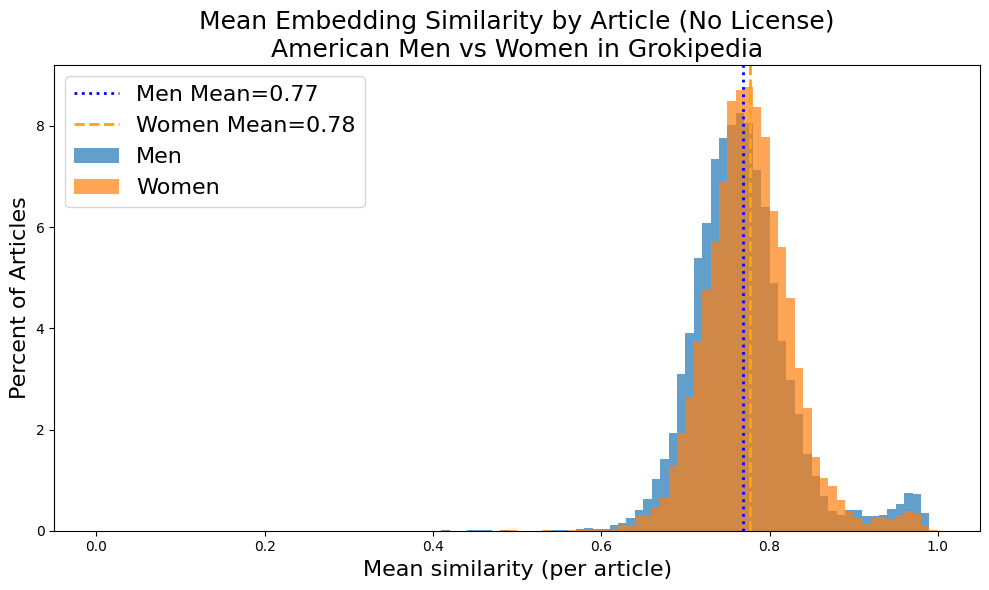

In [50]:
# Plot mean similarity (by page title) for American men and American women WITHOUT LICENSE

def load_name_set(filepath):
    with open(filepath, encoding='utf-8') as f:
        return set(line.strip().lower() for line in f if line.strip())

def normalize_title(s):
    return s.lower().replace("_", " ").strip()

# Load sets of names
men_path = "../results/demographic_analysis/american_men_in_grokipedia.txt"
women_path = "../results/demographic_analysis/american_women_in_grokipedia.txt"
wo_license_path = "../results/overall/grokipedia_wo_license.txt"

men_names = load_name_set(men_path)
women_names = load_name_set(women_path)
wo_license_names = load_name_set(wo_license_path)

# Only keep people without a license
men_names = men_names.intersection(wo_license_names)
women_names = women_names.intersection(wo_license_names)

# Normalize article titles in similarities DataFrame
similarities['normalized_article'] = similarities['title'].apply(normalize_title)

# Filter to only the articles that are in either men or women set (license-limited)
men_sim_df = similarities[similarities['normalized_article'].isin(men_names - women_names)].copy()
women_sim_df = similarities[similarities['normalized_article'].isin(women_names - men_names)].copy()

# Take the *mean similarity per page title* (in case there are multiple rows per article)
men_means = men_sim_df.groupby('normalized_article')['similarity'].mean()
women_means = women_sim_df.groupby('normalized_article')['similarity'].mean()

print(f"Number of unique American men in similarity df (wo_license): {len(men_means)}")
print(f"Number of unique American women in similarity df (wo_license): {len(women_means)}")

# Compute overall means and t-test
from scipy.stats import ttest_ind
mean_men = men_means.mean()
mean_women = women_means.mean()

ttest_res = ttest_ind(men_means, women_means, equal_var=False, nan_policy='omit')
pval = ttest_res.pvalue
stat = ttest_res.statistic

print(f"Mean of means (men, wo_license): {mean_men:.4f}")
print(f"Mean of means (women, wo_license): {mean_women:.4f}")
print(f"t-statistic: {stat:.3f}, p-value: {pval:.3e}")

# Plot histogram overlays, y axis is percent (distribution of *mean* similarity per name)
plt.figure(figsize=(10, 6))
bins = 100

men_counts, bin_edges = np.histogram(men_means, bins=bins, range=(0,1))
women_counts, _ = np.histogram(women_means, bins=bin_edges)

men_percents = men_counts / men_means.shape[0] * 100 if men_means.shape[0] > 0 else np.zeros_like(men_counts)
women_percents = women_counts / women_means.shape[0] * 100 if women_means.shape[0] > 0 else np.zeros_like(women_counts)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.bar(bin_centers, men_percents, width=(bin_edges[1] - bin_edges[0]), 
        color="tab:blue", alpha=0.7, label="Men", edgecolor=None)
plt.bar(bin_centers, women_percents, width=(bin_edges[1] - bin_edges[0]), 
        color="tab:orange", alpha=0.7, label="Women", edgecolor=None)

plt.axvline(x=mean_men, color="blue", linestyle=":", linewidth=2, 
            label=f"Men Mean={mean_men:.2f}")
plt.axvline(x=mean_women, color="orange", linestyle="--", linewidth=2, 
            label=f"Women Mean={mean_women:.2f}")

plt.xlabel("Mean similarity (per article)", fontsize=16)
plt.ylabel("Percent of Articles", fontsize=16)
plt.title("Mean Embedding Similarity by Article (No License)\nAmerican Men vs Women in Grokipedia", fontsize=18)

# extra_text = f"t={stat:.2f}, p={pval:.2e}"
# plt.legend(title=extra_text, fontsize=16, title_fontsize=14)
plt.legend(fontsize=16)


plt.tight_layout()
plt.savefig("../graphics/similarity_distribution_means_american_men_vs_women_percent_wo_license.pdf")
plt.show()


Number of unique African American men in similarity df: 2518
Number of unique African American women in similarity df: 2215
Mean of means (African American men): 0.7712
Mean of means (African American women): 0.7799
t-statistic: -5.686, p-value: 1.377e-08


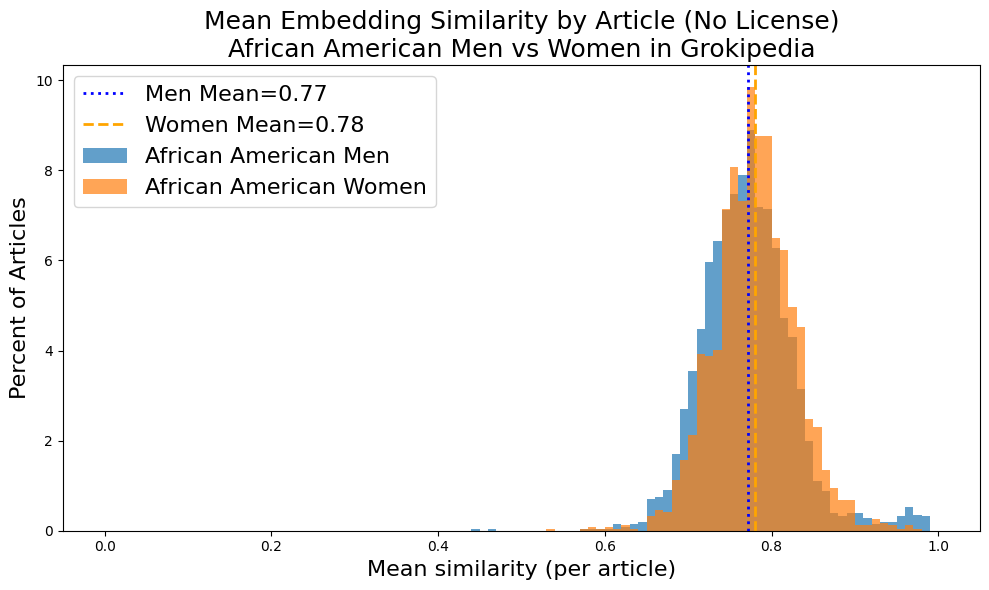

In [49]:
# Plot mean similarity (by page title) for African American men and African American women

# Load sets of names
afam_men_path = "../results/demographic_analysis/african_american_men_in_grokipedia.txt"
afam_women_path = "../results/demographic_analysis/african_american_women_in_grokipedia.txt"
afam_men_names = load_name_set(afam_men_path)
afam_women_names = load_name_set(afam_women_path)
wo_license_names = load_name_set(wo_license_path)

# Only keep people without a license
afam_men_names = afam_men_names.intersection(wo_license_names)
afam_women_names = afam_women_names.intersection(wo_license_names)

# Normalize article titles in similarities DataFrame
similarities['normalized_article'] = similarities['title'].apply(normalize_title)

# Filter to only the articles that are in men or women set (not both)
afam_men_unique = afam_men_names - afam_women_names
afam_women_unique = afam_women_names - afam_men_names

afam_men_sim_df = similarities[similarities['normalized_article'].isin(afam_men_unique)].copy()
afam_women_sim_df = similarities[similarities['normalized_article'].isin(afam_women_unique)].copy()

# Take the *mean similarity per page title* (in case there are multiple rows per article)
afam_men_means = afam_men_sim_df.groupby('normalized_article')['similarity'].mean()
afam_women_means = afam_women_sim_df.groupby('normalized_article')['similarity'].mean()

print(f"Number of unique African American men in similarity df: {len(afam_men_means)}")
print(f"Number of unique African American women in similarity df: {len(afam_women_means)}")

# Compute overall means and t-test
from scipy.stats import ttest_ind
mean_men = afam_men_means.mean()
mean_women = afam_women_means.mean()

ttest_res = ttest_ind(afam_men_means.values, afam_women_means.values, equal_var=False, nan_policy='omit')
pval = ttest_res.pvalue
stat = ttest_res.statistic

print(f"Mean of means (African American men): {mean_men:.4f}")
print(f"Mean of means (African American women): {mean_women:.4f}")
print(f"t-statistic: {stat:.3f}, p-value: {pval:.3e}")

# Plot histogram overlays, y axis is percent (distribution of *mean* similarity per name)
plt.figure(figsize=(10, 6))
bins = 100

men_counts, bin_edges = np.histogram(afam_men_means, bins=bins, range=(0,1))
women_counts, _ = np.histogram(afam_women_means, bins=bin_edges)

men_percents = (men_counts / afam_men_means.shape[0] * 100) if afam_men_means.shape[0] > 0 else np.zeros_like(men_counts)
women_percents = (women_counts / afam_women_means.shape[0] * 100) if afam_women_means.shape[0] > 0 else np.zeros_like(women_counts)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.bar(bin_centers, men_percents, width=(bin_edges[1] - bin_edges[0]), 
        color="tab:blue", alpha=0.7, label="African American Men", edgecolor=None)
plt.bar(bin_centers, women_percents, width=(bin_edges[1] - bin_edges[0]), 
        color="tab:orange", alpha=0.7, label="African American Women", edgecolor=None)

plt.axvline(x=mean_men, color="blue", linestyle=":", linewidth=2, 
            label=f"Men Mean={mean_men:.2f}")
plt.axvline(x=mean_women, color="orange", linestyle="--", linewidth=2, 
            label=f"Women Mean={mean_women:.2f}")

plt.xlabel("Mean similarity (per article)", fontsize=16)
plt.ylabel("Percent of Articles", fontsize=16)
plt.title("Mean Embedding Similarity by Article (No License)\nAfrican American Men vs Women in Grokipedia", fontsize=18)

# extra_text = f"t={stat:.2f}, p={pval:.2e}"
# plt.legend(title=extra_text, fontsize=16, title_fontsize=14)
plt.legend(fontsize=16)

plt.tight_layout()
plt.savefig("../graphics/similarity_distribution_means_african_american_men_vs_women_percent.pdf")
plt.show()


In [27]:
def get_reliability_shift_for_demographic(
    demographic_txt,
    reliability_df,
    result_dir='../results/overall/domains',
    fsuffix='_domains.json'
):
    """
    For a given demographic group (txt file of article names), constructs the
    reliability shift data (same format as the old 'find_reliability_shift_maximal_controversial')
    for all articles listed in the demographic file.

    Args:
        demographic_txt: Path to file (one article name per line, normalized as in JSON).
        reliability_df: DataFrame with 'domain' and 'status' columns.
        result_dir: Directory for wp_domains.json and grok_domains.json.
        fsuffix: Suffix for JSON files. Default '_domains.json'.

    Returns:
        List of tuples with article reliability shift metrics (see column order below).
    """
    import json

    # Load demographic group articles as a set
    with open(demographic_txt, 'r', encoding='utf-8') as f:
        article_set = set(line.strip() for line in f if line.strip())

    # Helper to get counts for a list of articles
    def get_article_reliability_counts(json_file, reliability_df, article_set):
        reliability_lookup = {}
        for _, row in reliability_df.iterrows():
            domain = row['domain']
            if domain:
                reliability_lookup[domain] = row.get('status', None)
        
        article_stats = {}
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        for article_dict in data:
            for article_title, domains in article_dict.items():
                key = article_title.lower().replace('_', ' ')
                if key not in article_set:
                    continue
                if isinstance(domains, dict):
                    rel_count = 0
                    unrel_count = 0
                    blacklist_count = 0
                    no_consensus_count = 0
                    deprecated_count = 0
                    other_count = 0
                    total_count = 0
                    for domain, count in domains.items():
                        total_count += count
                        if domain and domain in reliability_lookup:
                            status = reliability_lookup[domain]
                            if status == 'Generally reliable':
                                rel_count += count
                            elif status == 'Generally unreliable':
                                unrel_count += count
                            elif status == 'Deprecated':
                                deprecated_count += count
                            elif status == 'No consensus':
                                no_consensus_count += count
                            elif status == 'Blacklisted':
                                blacklist_count += count
                            else:
                                other_count += count
                        else:
                            other_count += count
                    article_stats[key] = (
                        article_title, rel_count, unrel_count, blacklist_count, no_consensus_count,
                        deprecated_count, other_count, total_count
                    )
        return article_stats

    # Get per-article data only for demographic group
    wp_json = f"{result_dir}/wp{fsuffix}"
    grok_json = f"{result_dir}/grok{fsuffix}"
    wp_dict = get_article_reliability_counts(wp_json, reliability_df, article_set)
    grok_dict = get_article_reliability_counts(grok_json, reliability_df, article_set)

    # Union of all articles found in either dataset
    all_articles = set(wp_dict.keys()) | set(grok_dict.keys())

    article_maximals = []
    for article in all_articles:
        wp_data = wp_dict.get(article, (article, 0, 0, 0, 0, 0, 0, 0))
        grok_data = grok_dict.get(article, (article, 0, 0, 0, 0, 0, 0, 0))
        _, wp_rel, wp_unrel, wp_blacklist, wp_no_consensus, wp_deprecated, wp_other, wp_total = wp_data
        _, grok_rel, grok_unrel, grok_blacklist, grok_no_consensus, grok_deprecated, grok_other, grok_total = grok_data
        # Calculate: (WP_reliable - WP_unreliable) - (grok_unreliable - grok_reliable)
        maximal_value = (wp_rel - wp_unrel) - (grok_unrel - grok_rel)
        article_maximals.append((
            article,
            wp_rel, wp_unrel, wp_blacklist, wp_no_consensus, wp_deprecated, wp_other, wp_total,
            grok_rel, grok_unrel, grok_blacklist, grok_no_consensus, grok_deprecated, grok_other, grok_total,
            maximal_value
        ))

    return article_maximals

columns = [
    'title', 'wp_reliable', 'wp_unreliable', 'wp_blacklist', 'wp_no_consensus', 'wp_deprecated', 'wp_other',
    'wp_total', 'grok_reliable', 'grok_unreliable', 'grok_blacklist', 'grok_no_consensus', 'grok_deprecated',
    'grok_other', 'grok_total', 'maximal'
]

In [28]:
prefix = '../results/demographic_analysis'
maximals = []
shifts = []
demographics = ['american_men', 'american_women', 'african_american_men', 'african_american_women', 'african_american_people']

for i, demographic in enumerate([f'{prefix}/{d}_in_grokipedia.txt' for d in demographics]):
    print(f"Processing demographic: {demographic}")
    maximals.append(get_reliability_shift_for_demographic(demographic, reliability_df))
    shifts.append(pd.DataFrame(maximals[i], columns=columns))

Processing demographic: ../results/demographic_analysis/american_men_in_grokipedia.txt
Processing demographic: ../results/demographic_analysis/american_women_in_grokipedia.txt
Processing demographic: ../results/demographic_analysis/african_american_men_in_grokipedia.txt
Processing demographic: ../results/demographic_analysis/african_american_women_in_grokipedia.txt
Processing demographic: ../results/demographic_analysis/african_american_people_in_grokipedia.txt


In [47]:
def plot_reliability_charts(filtered_df, demographic=None, fsuffix='', show=True, title=None):
    """
    Plots stacked bar + diagonal comparison charts using the given DataFrame:
    1. Stacked bar and overlay: Proportion of sources in each reliability category for Wikipedia and Grokipedia, with diagonal fills illustrating change.
    2. Bar chart: Percentage of articles containing at least one source of each type (not 'other') for Wikipedia and Grokipedia.

    Parameters:
        filtered_df (pd.DataFrame): DataFrame, typically filtered on articles of interest.
        demographic (str, optional): Demographic label for titles/filenames.
        show (bool): If True, calls plt.show() at end.
    """

    # --- Setup categories, labels, colors ---
    column_order = [
        'reliable', 'unreliable', 'blacklist', 'no_consensus', 'deprecated', 'other'
    ]
    display_names = {
        'reliable': 'Generally reliable',
        'unreliable': 'Generally unreliable',
        'blacklist': 'Blacklisted',
        'no_consensus': 'No consensus',
        'deprecated': 'Deprecated',
        'other': 'Other'
    }
    color_map = {
        'reliable': 'green',
        'unreliable': 'red',
        'blacklist': 'black',
        'no_consensus': 'yellow',
        'deprecated': 'orange',
        'other': 'grey'
    }

    # --- Aggregate counts as "wp" and "grok" "status" table ---
    agg = {
        'wp_reliable': filtered_df['wp_reliable'].sum(),
        'wp_unreliable': filtered_df['wp_unreliable'].sum(),
        'wp_blacklist': filtered_df['wp_blacklist'].sum(),
        'wp_no_consensus': filtered_df['wp_no_consensus'].sum(),
        'wp_deprecated': filtered_df['wp_deprecated'].sum(),
        'wp_other': filtered_df['wp_other'].sum(),
        'grok_reliable': filtered_df['grok_reliable'].sum(),
        'grok_unreliable': filtered_df['grok_unreliable'].sum(),
        'grok_blacklist': filtered_df['grok_blacklist'].sum(),
        'grok_no_consensus': filtered_df['grok_no_consensus'].sum(),
        'grok_deprecated': filtered_df['grok_deprecated'].sum(),
        'grok_other': filtered_df['grok_other'].sum(),
    }

    # Make DF of shape: index=['Wikipedia', 'Grokipedia'], columns=column_order
    wp_row = [agg[f'wp_{k}'] for k in column_order]
    grok_row = [agg[f'grok_{k}'] for k in column_order]
    prop_df = pd.DataFrame(
        [wp_row, grok_row],
        columns=column_order,
        index=['Wikipedia', 'Grokipedia']
    )
    prop_df_norm = prop_df.div(prop_df.sum(axis=1), axis=0).fillna(0)

    # --- Plotting stacked bars with diagonal overlays, make first plot narrower and better aligned ---
    labels = ['Wikipedia', 'Grokipedia']
    x = np.arange(len(labels))
    bar_sep = 0.09  # reduce gap between bars
    width = 0.18    # make bars narrower

    fig, axs = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.7]})

    # Format demographic strin
    # g for title and filename
    demographic_str = ""
    if demographic is not None:
        demographic_str = f" ({demographic.replace('_', ' ').title()})"

    # Set figure title (for whole figure)
    if title is not None:
        plot_title = title
    else:
        plot_title = f"Source Reliability Category Proportion: Wikipedia vs Grokipedia{demographic_str}"
    fig.suptitle(plot_title, fontsize=18, y=0.98)
    ax = axs[0]

    # Set up stacking
    bottoms = [0, 0]
    bars_wp = []
    bars_grok = []

    # For synchronized stacking, process in column order:
    for j, col in enumerate(column_order):
        color = color_map.get(col, 'grey')
        # WP bar proportions
        wp_prop = prop_df_norm.loc['Wikipedia', col]
        grok_prop = prop_df_norm.loc['Grokipedia', col]
        bar_wp = ax.bar(x[0] - width/2 - bar_sep/2, wp_prop, width=width,
                        bottom=bottoms[0], color=color, edgecolor='none', zorder=2, alpha=0.8)
        bar_grok = ax.bar(x[1] + width/2 + bar_sep/2, grok_prop, width=width,
                          bottom=bottoms[1], color=color, edgecolor='none', zorder=2, alpha=0.8)

        # Diagonal change fill
        wp_top = bottoms[0] + wp_prop
        grok_top = bottoms[1] + grok_prop
        ax.fill_between(
            [x[0] - width/2, x[1] + width/2],
            [wp_top, grok_top],
            [bottoms[0], bottoms[1]],
            color=color, alpha=0.25, zorder=1, linewidth=0
        )
        bars_wp.append(bar_wp)
        bars_grok.append(bar_grok)
        bottoms[0] += wp_prop
        bottoms[1] += grok_prop

    # Set axis ticks and labels
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=16)
    ax.set_ylabel("Proportion of Citations", fontsize=16)
    ax.set_title(f"Source Status Proportion{demographic_str}", fontsize=16)

    # Make axis tight with bars, remove excess white space
    ax.set_xlim(-0.23, 1.23)
    ax.set_ylim(bottom=0, top=1.01)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # Custom legend patch (color by status) - move inside plot to reduce whitespace
    legend_elements = [Patch(facecolor=color_map.get(col, 'grey'), label=display_names.get(col, col), alpha=0.8) for col in column_order]
    ax.legend(handles=legend_elements, title='Source Status', loc='upper center', framealpha=0.9)

    # Tighten subplot spacing to reduce whitespace
    fig.subplots_adjust(wspace=0.15, left=0.05, right=0.97, top=0.92, bottom=0.1)

    # ---- New plot: % of articles containing at least 1 in each source type (not 'other') ----

    ax2 = axs[1]
    main_types = ['reliable', 'unreliable', 'blacklist', 'no_consensus', 'deprecated']
    type_labels = [display_names[t] for t in main_types]
    bar_x = np.arange(len(main_types))
    bar_width = 0.36

    n_articles = len(filtered_df)
    percentages = {'Wikipedia': [], 'Grokipedia': []}
    for source_type in main_types:
        wp_col = f'wp_{source_type}'
        grok_col = f'grok_{source_type}'
        wp_count = (filtered_df[wp_col] > 0).sum()
        grok_count = (filtered_df[grok_col] > 0).sum()
        percentages['Wikipedia'].append(wp_count / n_articles * 100)
        percentages['Grokipedia'].append(grok_count / n_articles * 100)

    # Plot as side-by-side bars
    ax2.bar(bar_x - bar_width/2, percentages['Wikipedia'], bar_width,
           label='Wikipedia', color="#4977bc", edgecolor='black', alpha=0.7)
    ax2.bar(bar_x + bar_width/2, percentages['Grokipedia'], bar_width,
           label='Grokipedia', color="#e86b54", edgecolor='black', alpha=0.7)

    for i, (wp, gk) in enumerate(zip(percentages['Wikipedia'], percentages['Grokipedia'])):
        ax2.text(i - bar_width/2, wp + 1, f"{wp:.1f}%", ha='center', va='bottom', fontsize=10, color="#10426b")
        ax2.text(i + bar_width/2, gk + 1, f"{gk:.1f}%", ha='center', va='bottom', fontsize=10, color="#7a230c")

    ax2.set_xticks(bar_x)
    ax2.set_xticklabels(type_labels, rotation=14, fontsize=16)
    ax2.set_ylim(0, 105)
    ax2.set_ylabel("Percent of Articles", fontsize=16)
    ax2.set_title(f"% of Articles Citing Any Source in Category{demographic_str}", fontsize=16)
    ax2.legend(loc='upper right', fontsize=16)
    ax2.grid(axis='y', linestyle=':', alpha=0.4)

    fig.tight_layout()
    # Adjust filename to include demographic if given
    fname = '../graphics/overall_grok_wp_cite_composition'
    if demographic is not None:
        fname += f'_{demographic}'
    fname += f'_{fsuffix}.pdf' if fsuffix else '.pdf'
    fig.savefig(fname)

    if show:
        plt.show()

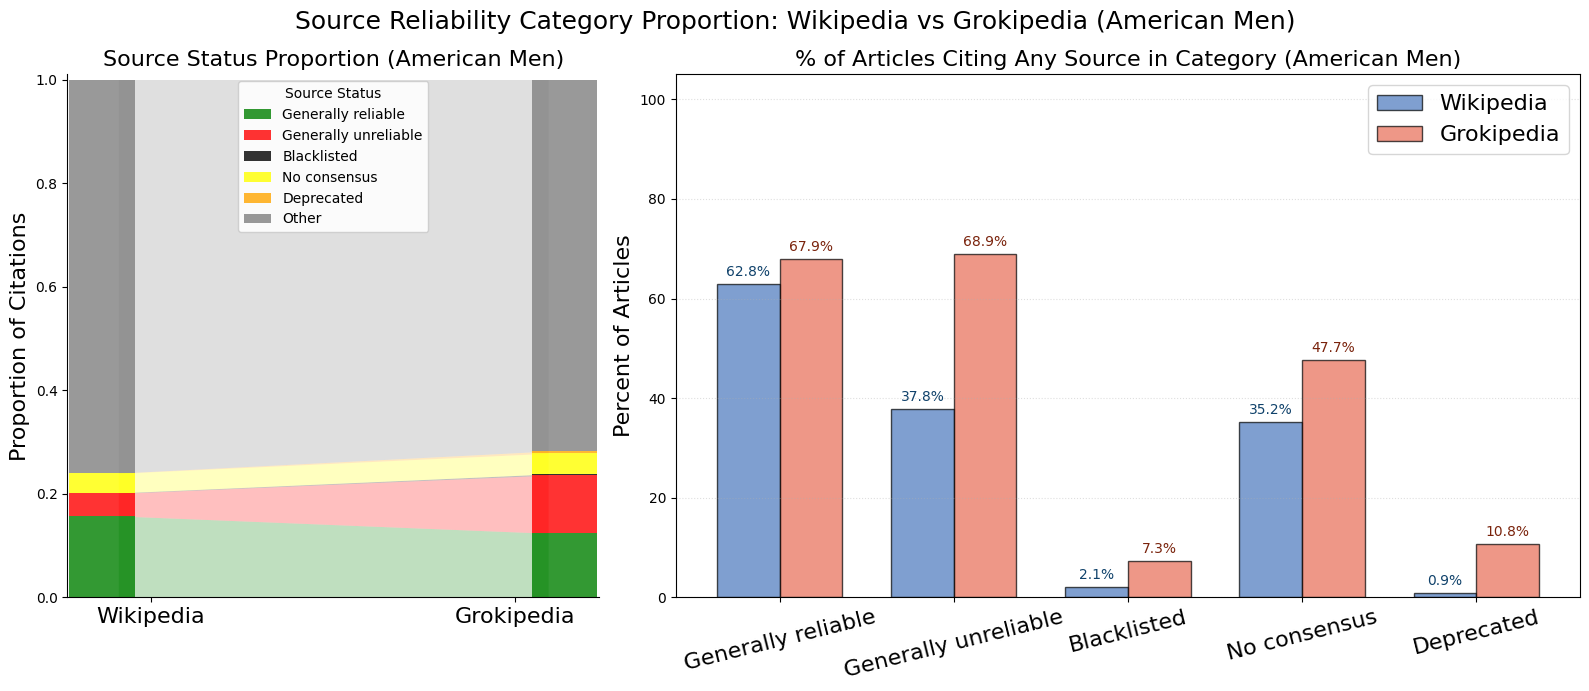

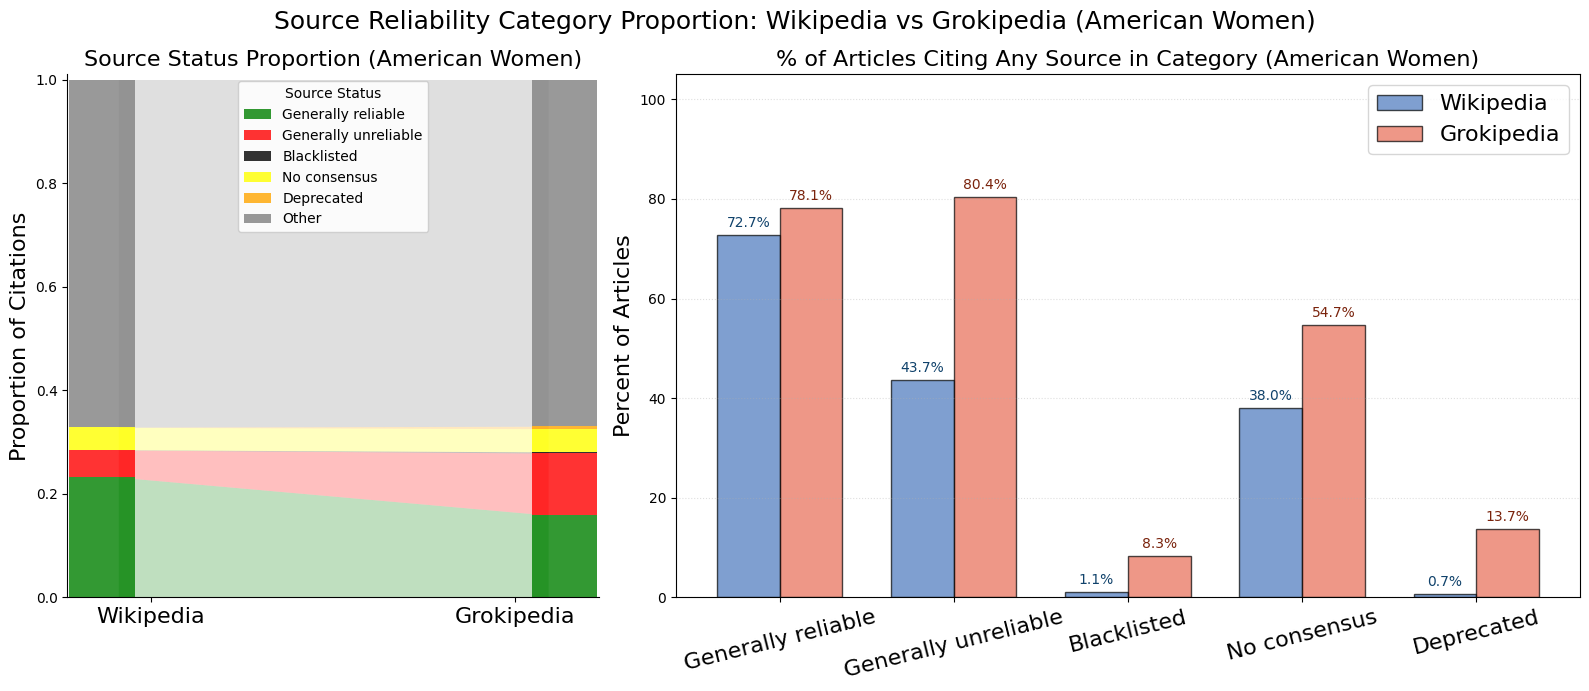

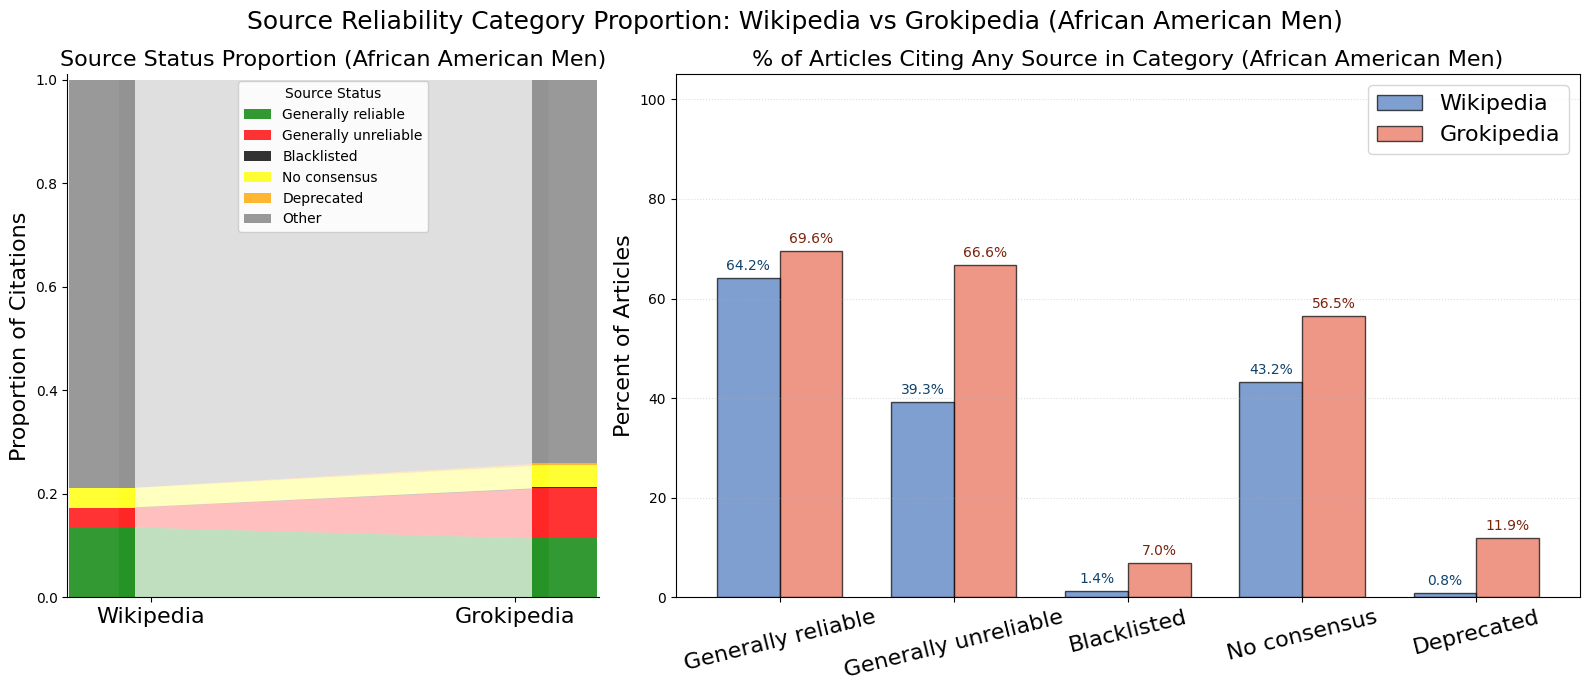

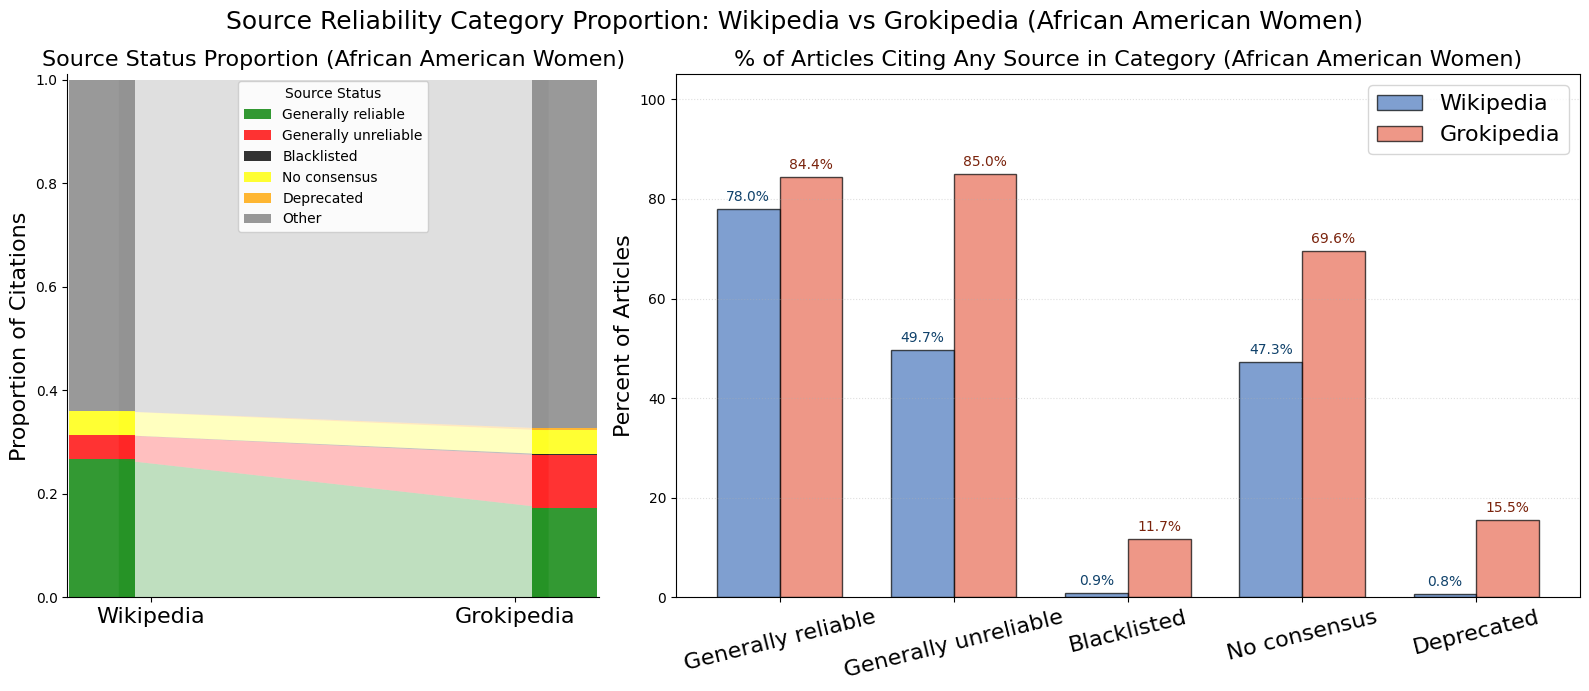

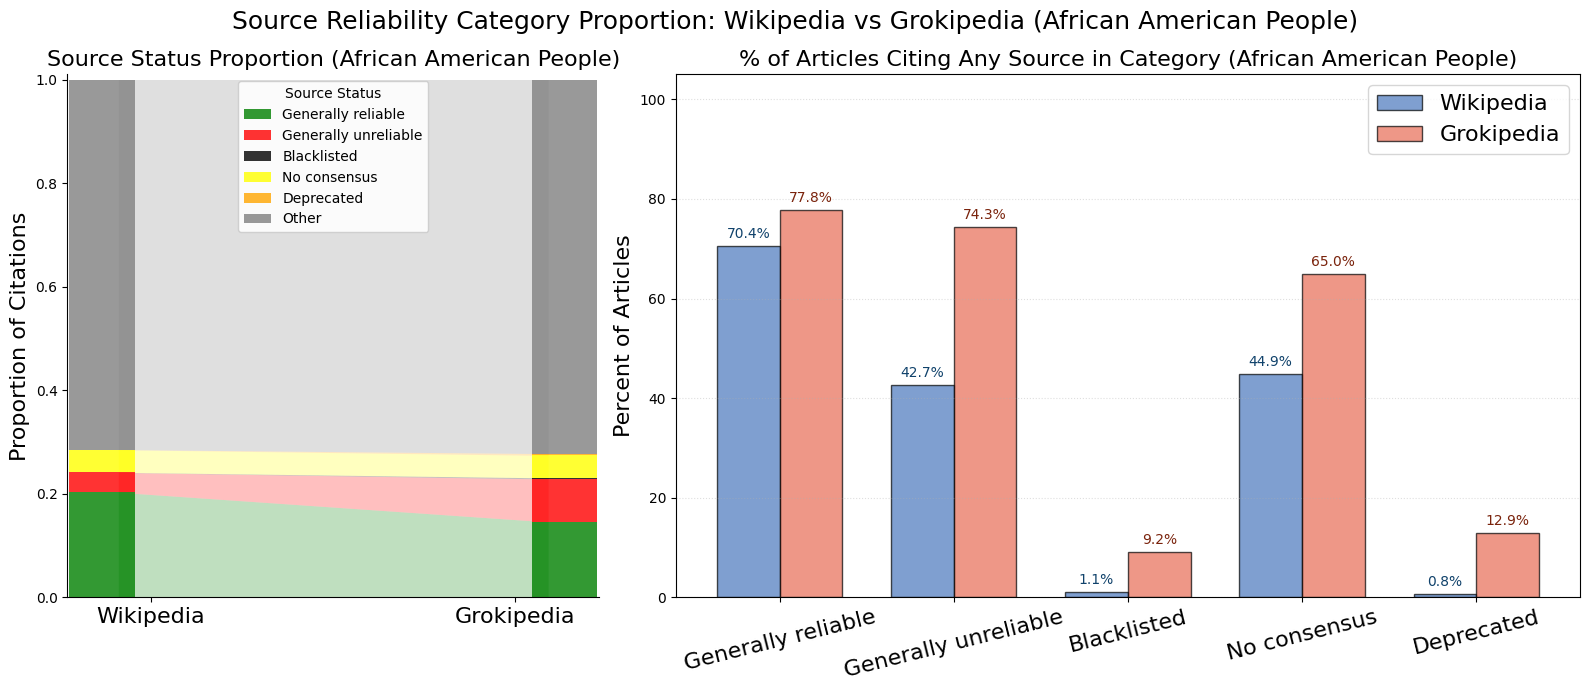

In [48]:
for demo, shift in zip(demographics, shifts):
    plot_reliability_charts(shift, demographic=demo, fsuffix=demo)

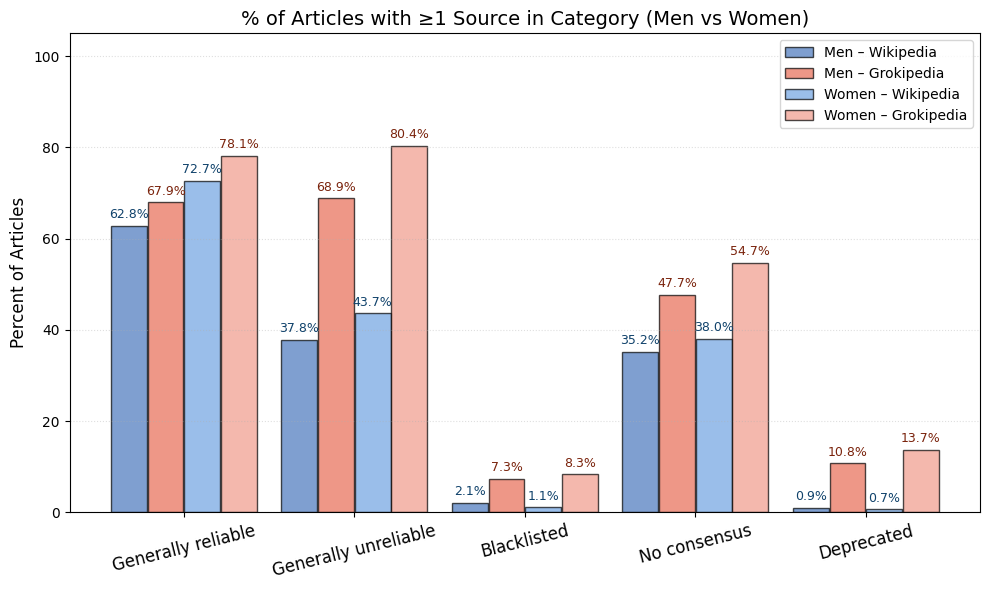

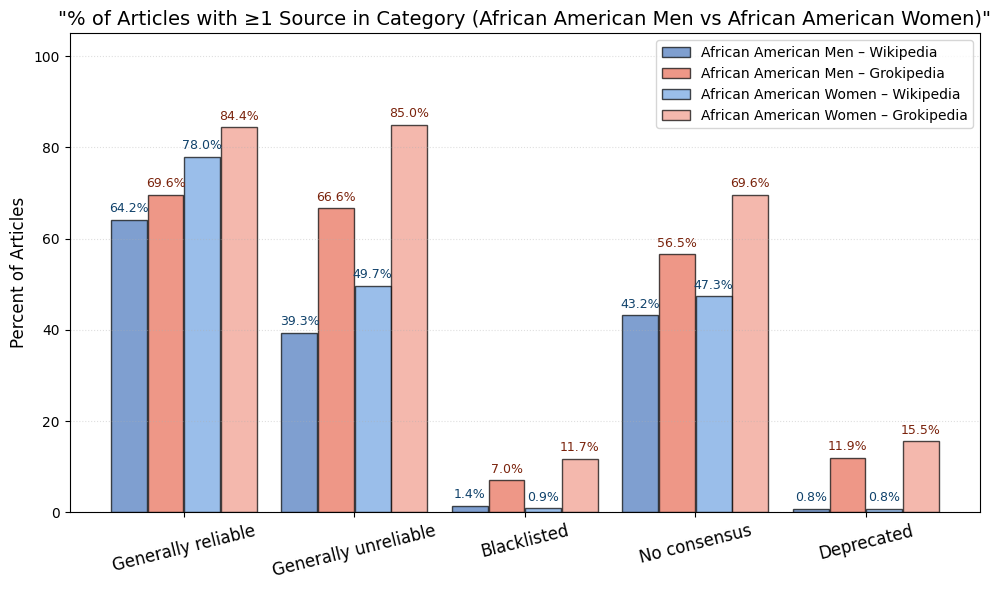

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_source_type_bars(df_men, df_women, show=True, title=None, save_path=None):
    """
    df_men / df_women: DataFrames with columns wp_<type> and grok_<type> (counts per article).
    Produces side-by-side bars for men vs women, for each source category.
    """
    display_names = {
        'reliable': 'Generally reliable',
        'unreliable': 'Generally unreliable',
        'blacklist': 'Blacklisted',
        'no_consensus': 'No consensus',
        'deprecated': 'Deprecated',
    }
    main_types = ['reliable', 'unreliable', 'blacklist', 'no_consensus', 'deprecated']
    type_labels = [display_names[t] for t in main_types]
    # bar_x = np.arange(len(main_types))
    # bar_width = 0.2

    def percent_any(df, source_type):
        col_wp = f'wp_{source_type}'
        col_gk = f'grok_{source_type}'
        n = len(df)
        wp = (df[col_wp] > 0).sum() / n * 100
        gk = (df[col_gk] > 0).sum() / n * 100
        return wp, gk

    men_pct = {'Wikipedia': [], 'Grokipedia': []}
    women_pct = {'Wikipedia': [], 'Grokipedia': []}
    for t in main_types:
        wp_m, gk_m = percent_any(df_men, t)
        wp_w, gk_w = percent_any(df_women, t)
        men_pct['Wikipedia'].append(wp_m)
        men_pct['Grokipedia'].append(gk_m)
        women_pct['Wikipedia'].append(wp_w)
        women_pct['Grokipedia'].append(gk_w)

    fig, ax = plt.subplots(figsize=(10, 6))
    # Men bars (left cluster)
    bar_width = 0.21   # narrower bars
    offset = 0.215      # bigger separation within each category
    bar_x = np.arange(len(main_types))

    men_wp_x = bar_x - 1.5*offset
    men_gk_x = bar_x - 0.5*offset
    women_wp_x = bar_x + 0.5*offset
    women_gk_x = bar_x + 1.5*offset

    labels = []
    for g in ['Men', 'Women']:
        for s in ['Wikipedia', 'Grokipedia']:
            labels.append(f'{g} – {s}') if not title else labels.append(f'African American {g} – {s}')

    ax.bar(men_wp_x, men_pct['Wikipedia'], bar_width,
        label=labels[0], color="#4977bc", edgecolor='black', alpha=0.7)
    ax.bar(men_gk_x, men_pct['Grokipedia'], bar_width,
        label=labels[1], color="#e86b54", edgecolor='black', alpha=0.7)
    ax.bar(women_wp_x, women_pct['Wikipedia'], bar_width,
        label=labels[2], color="#6fa3e2", edgecolor='black', alpha=0.7)
    ax.bar(women_gk_x, women_pct['Grokipedia'], bar_width,
        label=labels[3], color="#f09b8a", edgecolor='black', alpha=0.7)

    for i in range(len(main_types)):
        ax.text(men_wp_x[i], men_pct['Wikipedia'][i] + 1, f"{men_pct['Wikipedia'][i]:.1f}%",
                ha='center', va='bottom', fontsize=9, color="#10426b")
        ax.text(men_gk_x[i], men_pct['Grokipedia'][i] + 1, f"{men_pct['Grokipedia'][i]:.1f}%",
                ha='center', va='bottom', fontsize=9, color="#7a230c")
        ax.text(women_wp_x[i], women_pct['Wikipedia'][i] + 1, f"{women_pct['Wikipedia'][i]:.1f}%",
                ha='center', va='bottom', fontsize=9, color="#10426b")
        ax.text(women_gk_x[i], women_pct['Grokipedia'][i] + 1, f"{women_pct['Grokipedia'][i]:.1f}%",
                ha='center', va='bottom', fontsize=9, color="#7a230c")

    ax.set_xticks(bar_x)
    ax.set_xticklabels(type_labels, rotation=14, fontsize=12)
    ax.set_ylim(0, 105)
    ax.set_ylabel("Percent of Articles", fontsize=12)
    ax.set_title(title or "% of Articles with ≥1 Source in Category (Men vs Women)", fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
    if show:
        plt.show()

# Example usage (pass your filtered men/women dataframes):
plot_source_type_bars(shifts[0], shifts[1], show=True, save_path="men_women_sources.pdf")
plot_source_type_bars(shifts[2], shifts[3], show=True, title='"% of Articles with ≥1 Source in Category (African American Men vs African American Women)"', save_path="african_american_men_women_sources.pdf")

In [49]:
def find_reliability_shift_by_buckets_demographic(
    demographic_txt,
    lin_reliability,
    result_dir='../results/overall/domains',
    fsuffix='_domains.json'
):
    """
    For a given demographic group (txt file of article names), constructs the
    reliability bucket shift data (like the controversial bucket version) for all articles listed in the demographic file.

    Args:
        demographic_txt: Path to file (one article name per line, normalized as in JSON).
        lin_reliability: DataFrame with 'domain' and 'reliability_score' (or 'pc1') columns.
        result_dir: Directory for wp_domains.json and grok_domains.json.
        fsuffix: Suffix for JSON files. Default '_domains.json'.

    Returns:
        List of tuples with article reliability bucket shift metrics (see column order below).
    """
    import json
    import pandas as pd

    # Load demographic group articles as a set
    with open(demographic_txt, 'r', encoding='utf-8') as f:
        article_set = set(line.strip() for line in f if line.strip())

    # Define score buckets: 0.0-0.2, 0.2-0.4, ..., 0.8-1.0
    bucket_size = 0.2
    buckets = [(i * bucket_size, (i + 1) * bucket_size) for i in range(5)]
    bucket_labels = [f"{i * bucket_size:.1f}-{(i + 1) * bucket_size:.1f}" for i in range(5)]

    def get_bucket(score):
        if pd.isna(score):
            return None
        for i, (low, high) in enumerate(buckets):
            if low <= score < high:
                return i
        if score == 1.0:
            return 4
        return None

    def get_article_reliability_bucket_counts(json_file, lin_reliability, article_set):
        score_col = 'reliability_score' if 'reliability_score' in lin_reliability.columns else 'pc1'
        reliability_lookup = {}
        for _, row in lin_reliability.iterrows():
            domain = row['domain']
            if domain and pd.notna(row.get(score_col)):
                reliability_lookup[domain] = row[score_col]
        
        article_stats = []
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        for article_dict in data:
            for article_title, domains in article_dict.items():
                key = article_title.lower().replace('_', ' ')
                if key not in article_set:
                    continue
                if isinstance(domains, dict):
                    bucket_counts = {i: 0 for i in range(5)}
                    other_count = 0
                    total_count = 0
                    for domain, count in domains.items():
                        total_count += count
                        if domain and domain in reliability_lookup:
                            score = reliability_lookup[domain]
                            bucket_idx = get_bucket(score)
                            if bucket_idx is not None:
                                bucket_counts[bucket_idx] += count
                            else:
                                other_count += count
                        else:
                            other_count += count
                    article_stats.append((
                        article_title,
                        bucket_counts[0], bucket_counts[1], bucket_counts[2],
                        bucket_counts[3], bucket_counts[4], other_count, total_count
                    ))
        return article_stats

    # Get per-article data only for the demographic group
    wp_json = f"{result_dir}/wp{fsuffix}"
    grok_json = f"{result_dir}/grok{fsuffix}"
    wp_articles = get_article_reliability_bucket_counts(wp_json, lin_reliability, article_set)
    grok_articles = get_article_reliability_bucket_counts(grok_json, lin_reliability, article_set)

    # Dict by article title
    wp_dict = {art[0]: art for art in wp_articles}
    grok_dict = {art[0]: art for art in grok_articles}
    all_articles = set(wp_dict.keys()) | set(grok_dict.keys())

    article_bucket_shifts = []
    for article in all_articles:
        wp_data = wp_dict.get(article, (article, 0, 0, 0, 0, 0, 0, 0))
        grok_data = grok_dict.get(article, (article, 0, 0, 0, 0, 0, 0, 0))

        _, wp_b0, wp_b1, wp_b2, wp_b3, wp_b4, wp_other, wp_total = wp_data
        _, grok_b0, grok_b1, grok_b2, grok_b3, grok_b4, grok_other, grok_total = grok_data

        shift_b0 = wp_b0 - grok_b0
        shift_b1 = wp_b1 - grok_b1
        shift_b2 = wp_b2 - grok_b2
        shift_b3 = wp_b3 - grok_b3
        shift_b4 = wp_b4 - grok_b4
        weighted_shift = (shift_b0*1 + shift_b1*2 + shift_b2*3 + shift_b3*4 + shift_b4*5)

        article_bucket_shifts.append((
            article,
            wp_b0, wp_b1, wp_b2, wp_b3, wp_b4, wp_other, wp_total,
            grok_b0, grok_b1, grok_b2, grok_b3, grok_b4, grok_other, grok_total,
            shift_b0, shift_b1, shift_b2, shift_b3, shift_b4,
            weighted_shift
        ))

    return article_bucket_shifts

bucket_columns_demographic = [
    'title',
    'wp_bucket_0_0.2', 'wp_bucket_0.2_0.4', 'wp_bucket_0.4_0.6', 'wp_bucket_0.6_0.8', 'wp_bucket_0.8_1.0', 'wp_other', 'wp_total',
    'grok_bucket_0_0.2', 'grok_bucket_0.2_0.4', 'grok_bucket_0.4_0.6', 'grok_bucket_0.6_0.8', 'grok_bucket_0.8_1.0', 'grok_other', 'grok_total',
    'shift_bucket_0_0.2', 'shift_bucket_0.2_0.4', 'shift_bucket_0.4_0.6', 'shift_bucket_0.6_0.8', 'shift_bucket_0.8_1.0',
    'weighted_shift'
]


In [50]:
lin_reliability = pd.read_csv('../supplemental_data/news_reliability/LinRating_Join.csv')

In [54]:
prefix = '../results/demographic_analysis'
maximals = []
shifts = []
demographics = ['american_men', 'american_women', 'african_american_men', 'african_american_women', 'african_american_people']

for i, demographic in enumerate([f'{prefix}/{d}_in_grokipedia.txt' for d in demographics]):
    print(f"Processing demographic: {demographic}")
    maximals.append(find_reliability_shift_by_buckets_demographic(demographic, lin_reliability))
    shifts.append(pd.DataFrame(maximals[i], columns=bucket_columns_demographic))

Processing demographic: ../results/demographic_analysis/american_men_in_grokipedia.txt
Processing demographic: ../results/demographic_analysis/american_women_in_grokipedia.txt
Processing demographic: ../results/demographic_analysis/african_american_men_in_grokipedia.txt
Processing demographic: ../results/demographic_analysis/african_american_women_in_grokipedia.txt
Processing demographic: ../results/demographic_analysis/african_american_people_in_grokipedia.txt


In [52]:
def plot_reliability_bucket_charts(filtered_df, demographic=None, fsuffix='', show=True, title=None):
    """
    Plots stacked bar + diagonal comparison charts using reliability score buckets:
    1. Stacked bar and overlay: Proportion of sources in each reliability bucket for Wikipedia and Grokipedia, with diagonal fills illustrating change.
    2. Bar chart: Percentage of articles containing at least one source in each bucket for Wikipedia and Grokipedia.

    Parameters:
        filtered_df (pd.DataFrame): DataFrame with bucket columns (from find_reliability_shift_by_buckets)
        demographic (str, optional): Demographic label for titles/filenames.
        fsuffix (str): Suffix for output filename
        show (bool): If True, calls plt.show() at end.
        title (str): Optional custom title for the whole figure. If None, uses default title.
    """

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch
    import matplotlib.colors as mcolors

    # --- Setup buckets, labels, colors ---
    bucket_labels = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0', 'other']
    display_names = {
        '0.0-0.2': '0.0-0.2',
        '0.2-0.4': '0.2-0.4',
        '0.4-0.6': '0.4-0.6',
        '0.6-0.8': '0.6-0.8',
        '0.8-1.0': '0.8-1.0',
        'other': 'No score'
    }
    
    # Create color map: green (for 1.0), yellow (for 0.5), red (for 0.0), gray for 'other'
    from matplotlib.colors import to_hex, LinearSegmentedColormap
    
    # Create a green-yellow-red colormap, where 1.0 is green, 0.5 is yellow, 0.0 is red
    spect_cmap = LinearSegmentedColormap.from_list(
        "green_yellow_red", [(0.0, "#D73027"), (0.5, "#FEE08B"), (1.0, "#1A9850")]  # red, yellow, green
    )
    
    # Map bucket labels to their midpoint values for colormap
    bucket_midpoints = {
        '0.0-0.2': 0.1,  # Red end
        '0.2-0.4': 0.3,  # Red-yellow transition
        '0.4-0.6': 0.5,  # Yellow (middle)
        '0.6-0.8': 0.7,  # Yellow-green transition
        '0.8-1.0': 0.9,  # Green end
    }
    
    # Generate colors for each bucket using the colormap
    color_map = {}
    for bucket_label in bucket_labels:
        if bucket_label == 'other':
            color_map[bucket_label] = 'grey'
        else:
            midpoint = bucket_midpoints[bucket_label]
            color_map[bucket_label] = to_hex(spect_cmap(midpoint))

    # --- Aggregate counts as "wp" and "grok" bucket table ---
    # Map bucket labels to actual column name suffixes
    bucket_to_col = {
        '0.0-0.2': '0_0.2',
        '0.2-0.4': '0.2_0.4',
        '0.4-0.6': '0.4_0.6',
        '0.6-0.8': '0.6_0.8',
        '0.8-1.0': '0.8_1.0'
    }
    
    agg = {}
    for bucket_label in bucket_labels:
        if bucket_label == 'other':
            agg[f'wp_{bucket_label}'] = filtered_df['wp_other'].sum()
            agg[f'grok_{bucket_label}'] = filtered_df['grok_other'].sum()
        else:
            # Use the correct column name format
            col_suffix = bucket_to_col[bucket_label]
            agg[f'wp_{bucket_label}'] = filtered_df[f'wp_bucket_{col_suffix}'].sum()
            agg[f'grok_{bucket_label}'] = filtered_df[f'grok_bucket_{col_suffix}'].sum()

    # Make DF of shape: index=['Wikipedia', 'Grokipedia'], columns=bucket_labels
    wp_row = [agg[f'wp_{k}'] for k in bucket_labels]
    grok_row = [agg[f'grok_{k}'] for k in bucket_labels]
    prop_df = pd.DataFrame(
        [wp_row, grok_row],
        columns=bucket_labels,
        index=['Wikipedia', 'Grokipedia']
    )
    prop_df_norm = prop_df.div(prop_df.sum(axis=1), axis=0).fillna(0)

    # --- Plotting stacked bars with diagonal overlays ---
    labels = ['Wikipedia', 'Grokipedia']
    x = np.arange(len(labels))
    bar_sep = 0.09
    width = 0.18

    fig, axs = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.7]})
    ax = axs[0]

    # Set up stacking
    bottoms = [0, 0]
    bars_wp = []
    bars_grok = []

    # For synchronized stacking, process in bucket order:
    for j, bucket_label in enumerate(bucket_labels):
        color = color_map.get(bucket_label, 'grey')
        # WP bar proportions
        wp_prop = prop_df_norm.loc['Wikipedia', bucket_label]
        grok_prop = prop_df_norm.loc['Grokipedia', bucket_label]
        bar_wp = ax.bar(x[0] - width/2 - bar_sep/2, wp_prop, width=width,
                        bottom=bottoms[0], color=color, edgecolor='none', zorder=2)
        bar_grok = ax.bar(x[1] + width/2 + bar_sep/2, grok_prop, width=width,
                          bottom=bottoms[1], color=color, edgecolor='none', zorder=2)

        # Diagonal change fill
        wp_top = bottoms[0] + wp_prop
        grok_top = bottoms[1] + grok_prop
        ax.fill_between(
            [x[0] - width/2, x[1] + width/2],
            [wp_top, grok_top],
            [bottoms[0], bottoms[1]],
            color=color, alpha=0.25, zorder=1, linewidth=0
        )
        bars_wp.append(bar_wp)
        bars_grok.append(bar_grok)
        bottoms[0] += wp_prop
        bottoms[1] += grok_prop

    # Set axis ticks and labels
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=16)
    ax.set_ylabel("Proportion of Citations", fontsize=16)

    # Include demographic in axis/plot titles if provided
    demographic_str = f" ({demographic.replace('_', ' ').title()})" if demographic is not None else ""
    if title is not None:
        plot_title = title
    else:
        plot_title = f"Source Reliability Score Proportion: Wikipedia vs Grokipedia{demographic_str}"
    ax.set_title(f"Source Reliability Score Proportion{demographic_str}", fontsize=16)

    # Make axis tight with bars
    ax.set_xlim(-0.23, 1.23)
    ax.set_ylim(bottom=0, top=1.01)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # Custom legend patch (color by bucket) - reversed order - move inside plot to reduce whitespace
    legend_elements = [Patch(facecolor=color_map.get(bucket_label, 'grey'), label=display_names.get(bucket_label, bucket_label), alpha=0.55) for bucket_label in reversed(bucket_labels)]
    ax.legend(handles=legend_elements, title='Reliability Score', loc='upper center', framealpha=0.9)

    # Set figure title (for whole figure)
    fig.suptitle(plot_title, fontsize=18, y=0.98)
    
    # Tighten subplot spacing to reduce whitespace (leave room for suptitle)
    fig.subplots_adjust(wspace=0.15, left=0.05, right=0.97, top=0.88, bottom=0.1)

    # ---- New plot: % of articles containing at least 1 in each bucket ----
    ax2 = axs[1]
    main_buckets = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
    bucket_display_labels = [display_names[b] for b in main_buckets]
    bar_x = np.arange(len(main_buckets))
    bar_width = 0.36

    n_articles = len(filtered_df)
    percentages = {'Wikipedia': [], 'Grokipedia': []}
    for bucket_label in main_buckets:
        # Use the correct column name format
        col_suffix = bucket_to_col[bucket_label]
        wp_col = f'wp_bucket_{col_suffix}'
        grok_col = f'grok_bucket_{col_suffix}'
        wp_count = (filtered_df[wp_col] > 0).sum()
        grok_count = (filtered_df[grok_col] > 0).sum()
        percentages['Wikipedia'].append(wp_count / n_articles * 100)
        percentages['Grokipedia'].append(grok_count / n_articles * 100)

    # Plot as side-by-side bars with blue/red scheme (same as reliability chart)
    wp_color = "#4977bc"  # Blue for Wikipedia
    grok_color = "#e86b54"  # Red for Grokipedia
    ax2.bar(bar_x - bar_width/2, percentages['Wikipedia'], bar_width,
           label='Wikipedia', color=wp_color, edgecolor='black', alpha=0.7)
    ax2.bar(bar_x + bar_width/2, percentages['Grokipedia'], bar_width,
           label='Grokipedia', color=grok_color, edgecolor='black', alpha=0.7)

    for i, (wp, gk) in enumerate(zip(percentages['Wikipedia'], percentages['Grokipedia'])):
        ax2.text(i - bar_width/2, wp + 1, f"{wp:.1f}%", ha='center', va='bottom', fontsize=10, color="#10426b")
        ax2.text(i + bar_width/2, gk + 1, f"{gk:.1f}%", ha='center', va='bottom', fontsize=10, color="#7a230c")

    ax2.set_xticks(bar_x)
    ax2.set_xticklabels(bucket_display_labels, rotation=14, fontsize=16)
    ax2.set_ylim(0, 105)
    ax2.set_ylabel("Percent of Articles", fontsize=16)
    ax2.set_title(f"% of Articles Citing Any Source in Reliability Bucket{demographic_str}", fontsize=16)
    ax2.legend(loc='upper left', fontsize=16)
    ax2.grid(axis='y', linestyle=':', alpha=0.4)

    fig.tight_layout()
    # Adjust filename to include demographic if given
    fname = '../graphics/overall_grok_wp_cite_composition_lin'
    if demographic is not None:
        fname += f'_{demographic}'
    fname += f'_{fsuffix}.pdf' if fsuffix else '.pdf'
    fig.savefig(fname)

    if show:
        plt.show()


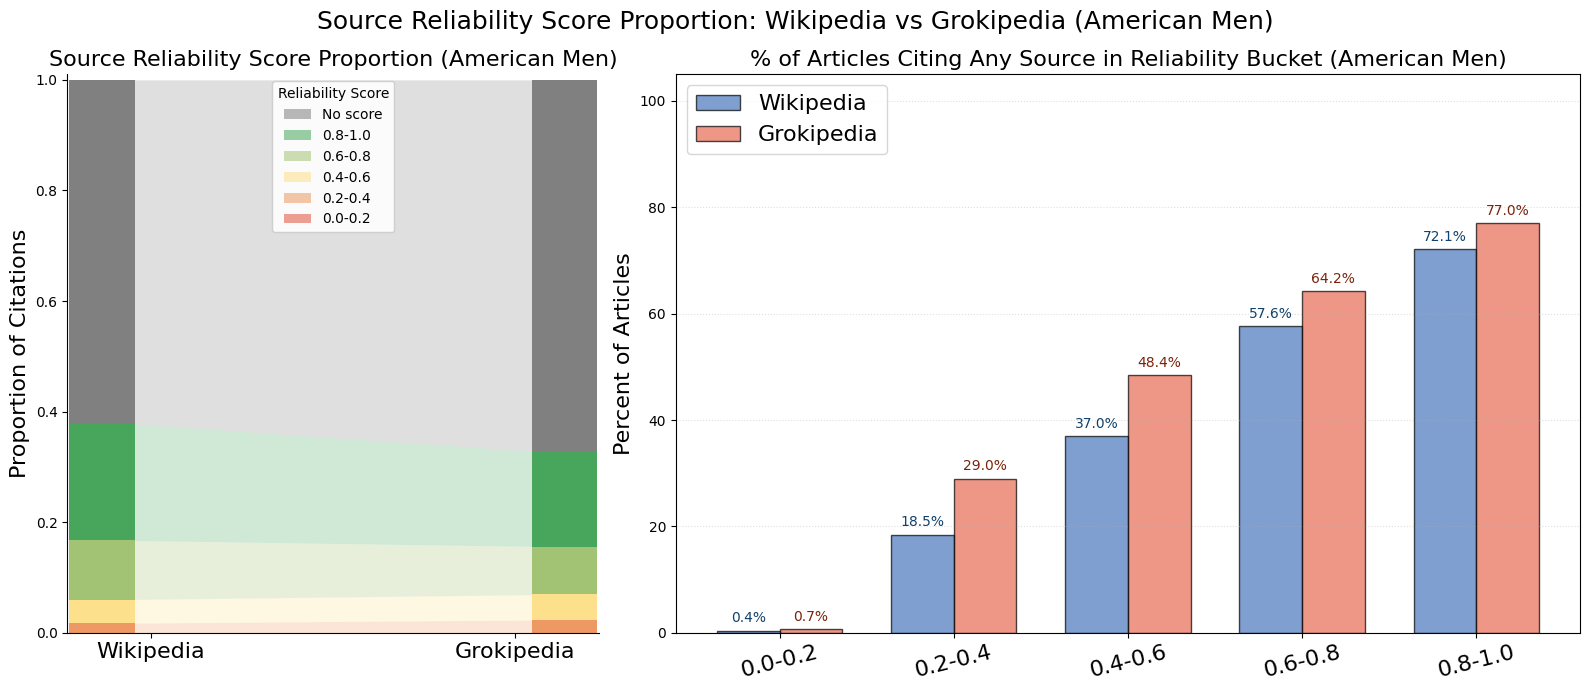

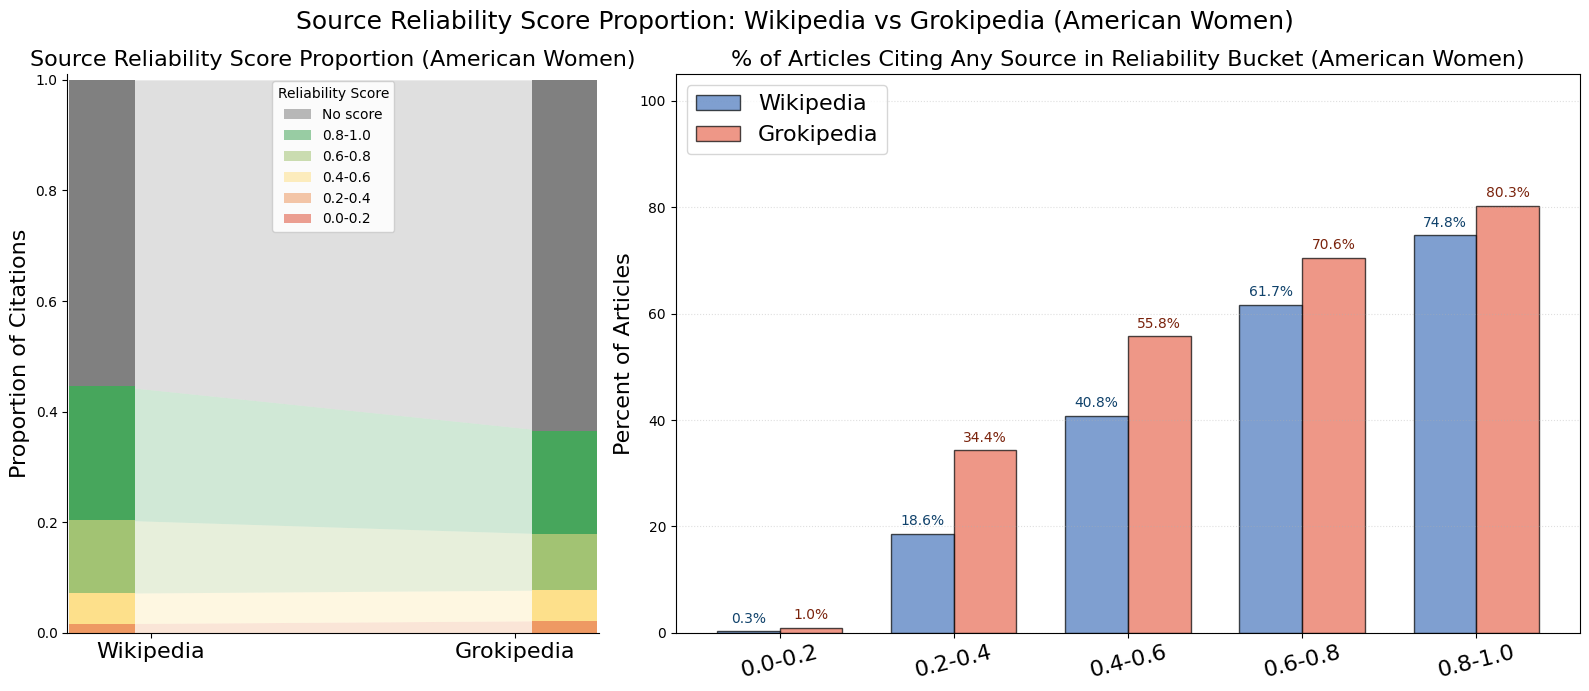

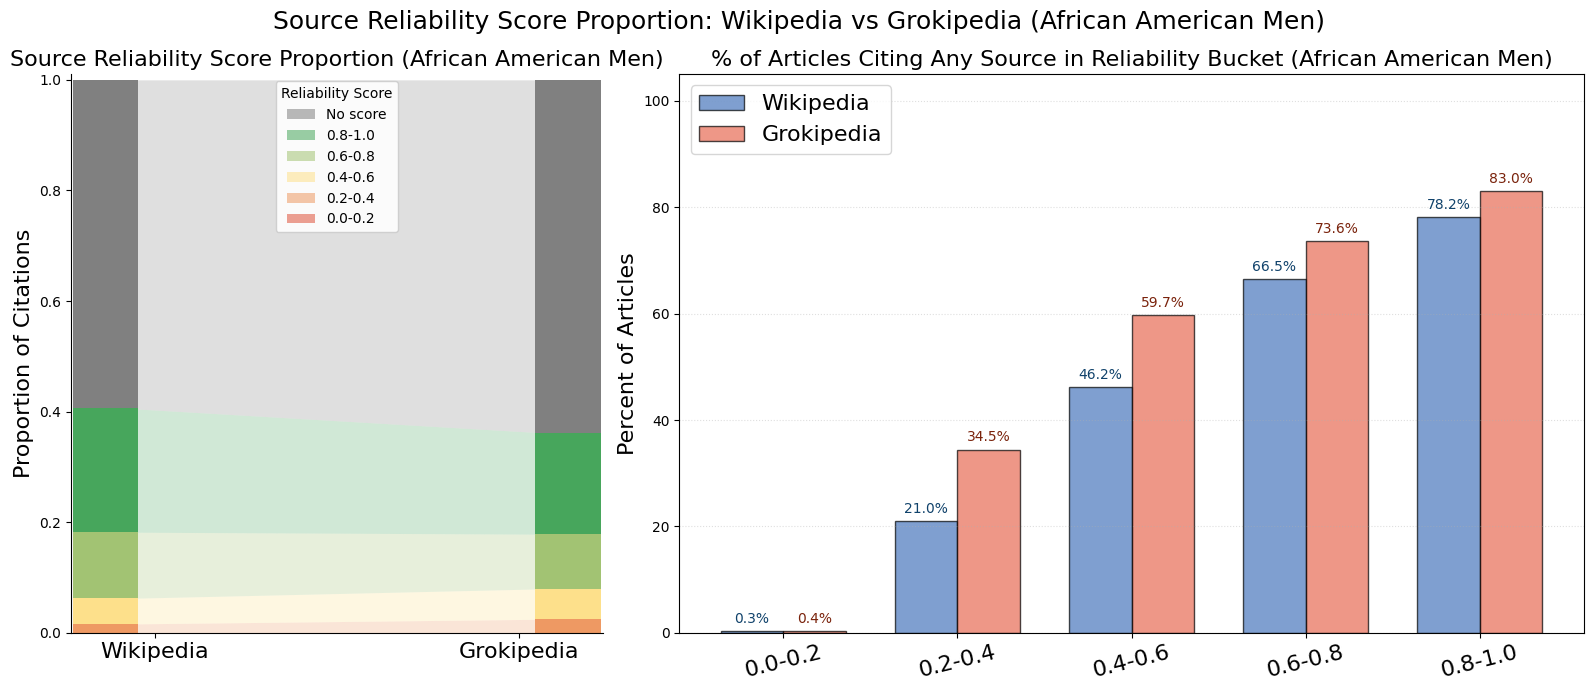

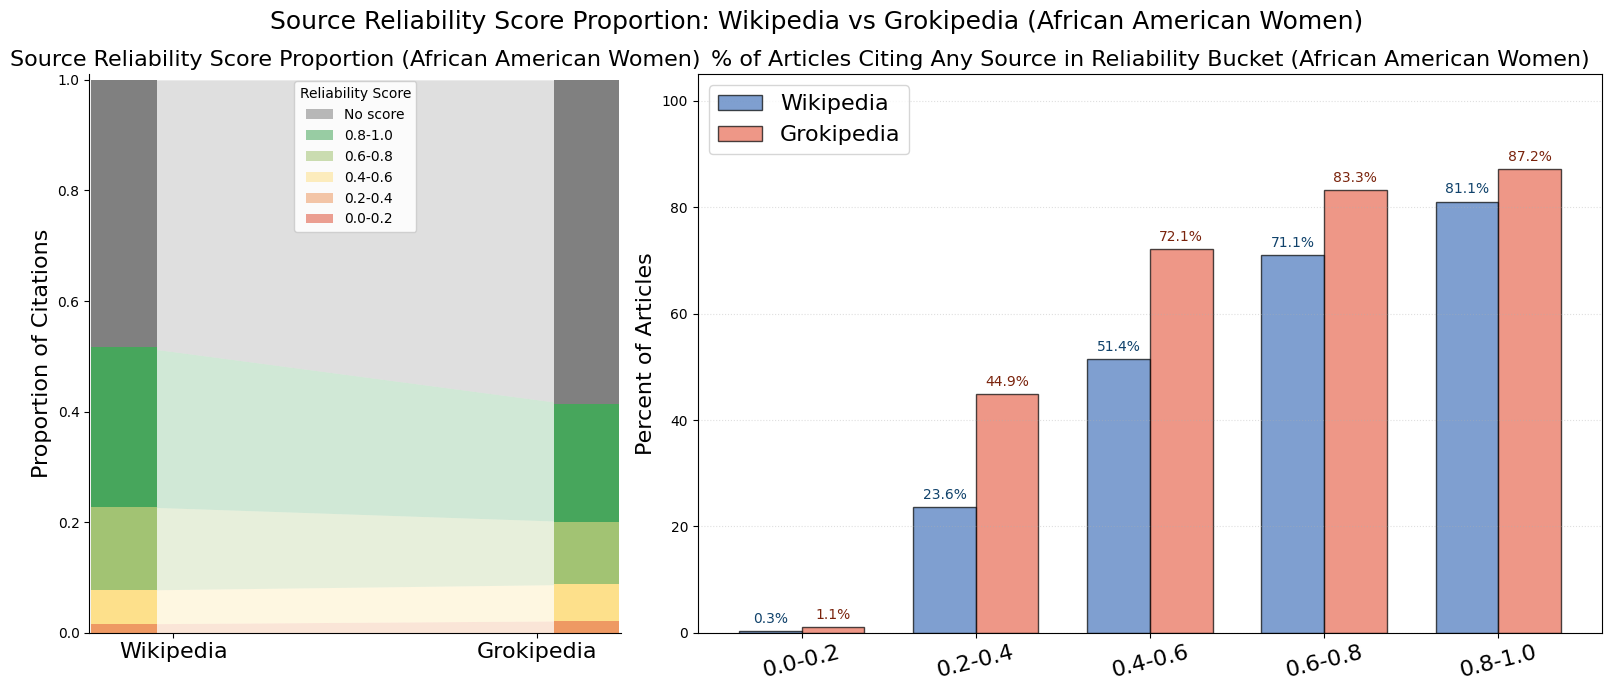

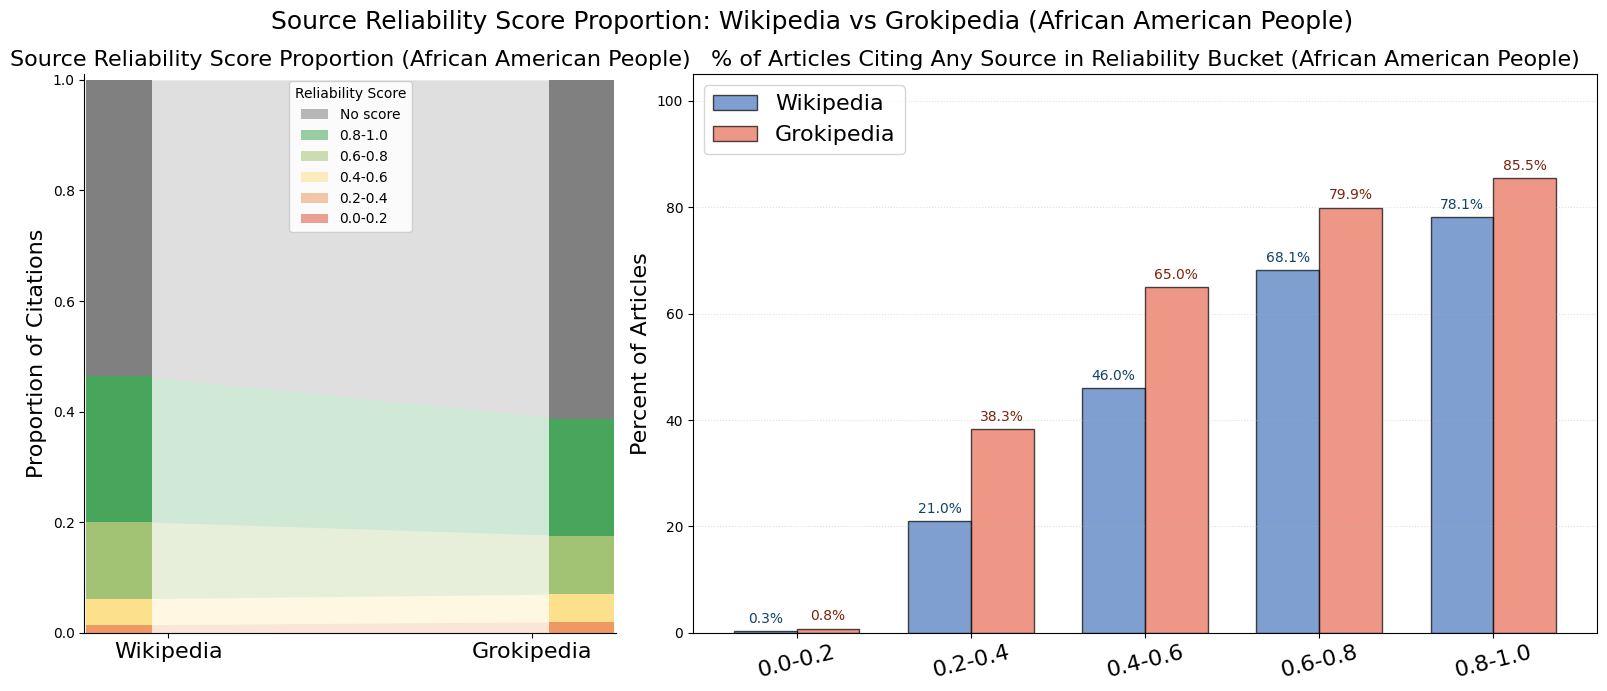

: 

In [ ]:
for demo, shift in zip(demographics, shifts):
    plot_reliability_bucket_charts(shift, demographic=demo, fsuffix=demo)

Number of controversial articles in similarity df: 46217
Number of non-controversial articles in similarity df: 6209577
Controversial Mean: 0.7262
Non-controversial Mean: 0.8155
t-statistic: -212.942, p-value: 0.000e+00


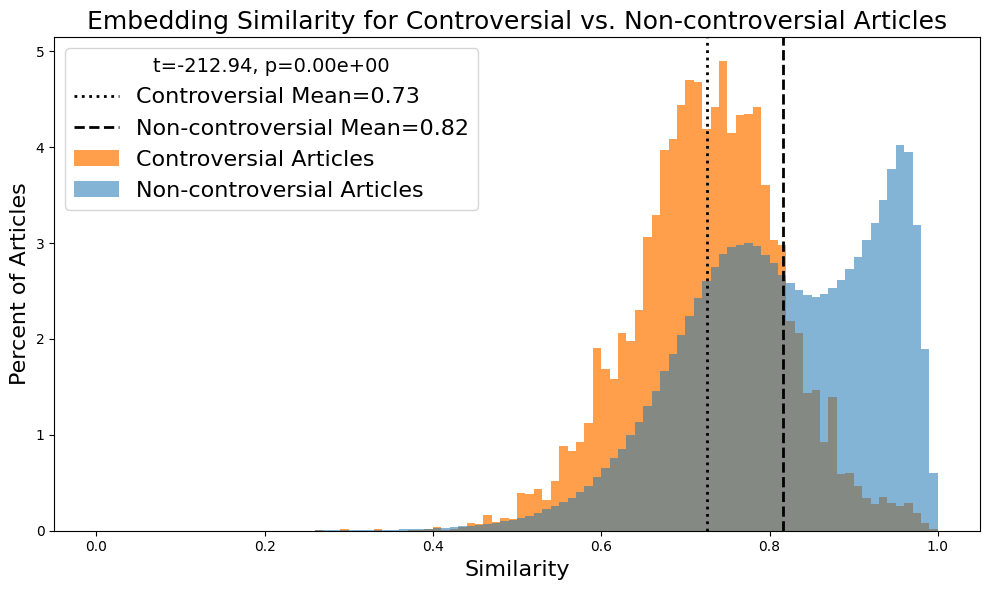

In [ ]:
# Compare embedding similarities between Wikipedia and Grokipedia for controversial vs. non-controversial articles

from scipy.stats import ttest_ind

# Read controversial article titles from file
controversial_titles = set()
with open("../results/controversial/controversial_pages_in_grokipedia.txt") as f:
    for line in f:
        title = line.strip()
        if title:
            controversial_titles.add(title.lower())

def normalize_title(s):
    return s.lower().replace("_", " ").strip()

# Normalize the article titles
similarities['normalized_article'] = similarities['title'].apply(normalize_title)

# Split into controversial/non-controversial sets
cont_sim_df = similarities[similarities['normalized_article'].isin(controversial_titles)].copy()
noncont_sim_df = similarities[~similarities['normalized_article'].isin(controversial_titles)].copy()

print(f"Number of controversial articles in similarity df: {len(cont_sim_df)}")
print(f"Number of non-controversial articles in similarity df: {len(noncont_sim_df)}")

cont_mean = cont_sim_df["similarity"].mean()
noncont_mean = noncont_sim_df["similarity"].mean()

# Compute t-test for difference in means
ttest_res = ttest_ind(cont_sim_df["similarity"], noncont_sim_df["similarity"], equal_var=False, nan_policy='omit')
pval = ttest_res.pvalue
stat = ttest_res.statistic

print(f"Controversial Mean: {cont_mean:.4f}")
print(f"Non-controversial Mean: {noncont_mean:.4f}")
print(f"t-statistic: {stat:.3f}, p-value: {pval:.3e}")

# Plot histogram overlays, y axis as percentage (not density)
plt.figure(figsize=(10, 6))
bins = 100

# Get bin counts (not density), then scale to percent
cont_counts, bin_edges = np.histogram(cont_sim_df["similarity"], bins=bins, range=(0,1))
noncont_counts, _ = np.histogram(noncont_sim_df["similarity"], bins=bin_edges)

cont_percents = cont_counts / cont_sim_df.shape[0] * 100 if cont_sim_df.shape[0] > 0 else np.zeros_like(cont_counts)
noncont_percents = noncont_counts / noncont_sim_df.shape[0] * 100 if noncont_sim_df.shape[0] > 0 else np.zeros_like(noncont_counts)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.bar(bin_centers, cont_percents, width=(bin_edges[1] - bin_edges[0]), 
        color="tab:orange", alpha=0.75, label="Controversial Articles", edgecolor=None)
plt.bar(bin_centers, noncont_percents, width=(bin_edges[1] - bin_edges[0]), 
        color="tab:blue", alpha=0.55, label="Non-controversial Articles", edgecolor=None)

plt.axvline(x=cont_mean, color="black", linestyle=":", linewidth=2, 
            label=f"Controversial Mean={cont_mean:.2f}")
plt.axvline(x=noncont_mean, color="black", linestyle="--", linewidth=2, 
            label=f"Non-controversial Mean={noncont_mean:.2f}")

plt.xlabel("Similarity", fontsize=16)
plt.ylabel("Percent of Articles", fontsize=16)
plt.title("Embedding Similarity for Controversial vs. Non-controversial Articles", fontsize=18)

# Add significance annotation to legend/title
extra_text = f"t={stat:.2f}, p={pval:.2e}"
plt.legend(title=extra_text, fontsize=16, title_fontsize=14)

plt.tight_layout()
plt.savefig("../graphics/similarity_distribution_controversial_vs_noncontroversial_percent.pdf")
plt.show()


In [1]:
# create index of the data for fast lookup and save as a pickle (.pkl) file

import json
import pickle

def _norm(s: str) -> str:
    return " ".join((s or "").strip().lower().split())

def stream_ndjson(path):
    """Yields objects (dicts) one at a time from an .ndjson file."""
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                yield json.loads(line)

def build_title_pointer_index(path, title_field="name", norm_func=_norm):
    """
    Index file offsets of each normalized title for later recovery.
    Returns {normalized_title: file_offset}
    """
    idx = {}
    with open(path, "r", encoding="utf-8") as f:
        pos = 0
        for line in f:
            # Record position before reading this line
            line_start = pos
            
            if line.strip():
                obj = json.loads(line)
                title = obj.get(title_field, '')
                if title:
                    idx[norm_func(title)] = line_start
            
            # Update position by adding the byte length of this line
            pos += len(line.encode('utf-8'))
    
    return idx

def build_grokipedia_file_map(fname, norm_func=_norm):
    """
    Maps normalized title to (filename, offset within file) for all Grokipedia jsonl files.
    Returns {normalized_title: (filename, file_offset)}
    """
    idx = {}
    with open(fname, "r", encoding="utf-8") as f:
        pos = 0
        for line in f:
            # Record position before reading this line
            line_start = pos
            
            if line.strip():
                obj = json.loads(line)
                title = obj.get('data', {}).get('main_title', '')
                if title:
                    idx[norm_func(title)] = (fname, line_start)
            
            # Update position by adding the byte length of this line
            pos += len(line.encode('utf-8'))
    
    return idx

def get_object_at_offset(path, offset):
    with open(path, "r", encoding="utf-8") as f:
        f.seek(offset)
        line = f.readline()
        return json.loads(line)

In [2]:
def find_reliability_shift_maximal(reliability_df, 
                                    grok_v01_idx_path='../results/overall/cached_grok_idx.pkl',
                                    grok_v02_idx_path='../results/v0.2_scrape/cached_grokipedia_idx_v0_2.pkl',
                                    wiki_idx_path='../results/overall/cached_wiki_idx.pkl',
                                    grok_v01_jsonl_path='../grokipedia_scrape.ndjson',
                                    grok_v02_jsonl_path='../results/v0.2_scrape/scraped_data.jsonl',
                                    wiki_jsonl_path='../grokipedia_wikipedia_articles.ndjson'):
    """
    Find articles where (WP_reliable - WP_unreliable) - (grok_unreliable - grok_reliable) is maximal.
    This identifies pages that went from well-sourced (reliable) in WP to poorly-sourced (unreliable) in Grok.
    
    Uses cached index files to efficiently load pages by offset. 
    Only processes articles that exist in ALL THREE sources (Wikipedia, Grokipedia v0.1, and v0.2).
    Keyed on v0.2 titles - iterates over v0.2 index and requires matching entries in Wikipedia and v0.1.
    
    Args:
        reliability_df: DataFrame with 'domain' and 'status' columns
        grok_v01_idx_path: Path to cached Grokipedia v0.1 index pickle file
        grok_v02_idx_path: Path to cached Grokipedia v0.2 index pickle file
        wiki_idx_path: Path to cached Wikipedia index pickle file
        grok_v01_jsonl_path: Path to Grokipedia v0.1 scraped data JSONL file
        grok_v02_jsonl_path: Path to Grokipedia v0.2 scraped data JSONL file
        wiki_jsonl_path: Path to Wikipedia articles JSONL file
    
    Returns:
        List of tuples with article shift data, including v0.1 and v0.2 Grokipedia data
    """
    import pickle
    from urllib.parse import urlparse
    import re
        
    def stem_domain(domain):
        # Remove common www/amp/mobile etc, keep only base domain
        if domain.startswith("www."):
            domain = domain[4:]
        # Remove mobile/amp subdomains if desired
        domain = re.sub(r"^(m|amp|en|web|mobile)\.", "", domain)
        return domain.lower()
    
    # Load cached indexes
    print("Loading cached indexes...")
    with open(grok_v01_idx_path, 'rb') as f:
        grok_v01_idx = pickle.load(f)
    with open(grok_v02_idx_path, 'rb') as f:
        grok_v02_idx = pickle.load(f)
    with open(wiki_idx_path, 'rb') as f:
        wiki_idx = pickle.load(f)
    
    print(f"  Grokipedia v0.1 index: {len(grok_v01_idx)} entries")
    print(f"  Grokipedia v0.2 index: {len(grok_v02_idx)} entries")
    print(f"  Wikipedia index: {len(wiki_idx)} entries")
    
    # Create lookup dict for reliability status by normalized domain
    reliability_lookup = {}
    for _, row in reliability_df.iterrows():
        domain = row['domain']
        if domain:
            stemmed = stem_domain(domain)
            reliability_lookup[stemmed] = row.get('status', None)
    
    def get_article_reliability_counts_from_page(page_obj, is_grok=True):
        """Extract references from a page object and count by reliability status."""
        rel_count = 0
        unrel_count = 0
        blacklist_count = 0
        no_consensus_count = 0
        deprecated_count = 0
        other_count = 0
        total_count = 0
        
        if is_grok:
            # Grokipedia structure: data['references'] with link['href']
            refs = page_obj.get('data', {}).get('references', [])
            for ref in refs:
                link = ref.get('link') if isinstance(ref, dict) else None
                href = link.get('href') if (link and isinstance(link, dict)) else None
                if href:
                    domain = urlparse(href).netloc
                    if domain:
                        stemmed = stem_domain(domain)
                        total_count += 1
                        if stemmed in reliability_lookup:
                            status = reliability_lookup[stemmed]
                            if status == 'Generally reliable':
                                rel_count += 1
                            elif status == 'Generally unreliable':
                                unrel_count += 1
                            elif status == 'Deprecated':
                                deprecated_count += 1
                            elif status == 'No consensus':
                                no_consensus_count += 1
                            elif status == 'Blacklisted':
                                blacklist_count += 1
                            else:
                                other_count += 1
                        else:
                            other_count += 1
        else:
            # Wikipedia structure: references with metadata['url']
            refs = page_obj.get('references', [])
            for ref in refs:
                metadata = ref.get('metadata') if isinstance(ref, dict) else None
                url = metadata.get('url') if (metadata and isinstance(metadata, dict)) else None
                if url:
                    domain = urlparse(url).netloc
                    if domain:
                        stemmed = stem_domain(domain)
                        total_count += 1
                        if stemmed in reliability_lookup:
                            status = reliability_lookup[stemmed]
                            if status == 'Generally reliable':
                                rel_count += 1
                            elif status == 'Generally unreliable':
                                unrel_count += 1
                            elif status == 'Deprecated':
                                deprecated_count += 1
                            elif status == 'No consensus':
                                no_consensus_count += 1
                            elif status == 'Blacklisted':
                                blacklist_count += 1
                            else:
                                other_count += 1
                        else:
                            other_count += 1
        
        return (rel_count, unrel_count, blacklist_count, no_consensus_count, deprecated_count, other_count, total_count)
    
    # Process all articles in Grokipedia v0.2 index that also exist in Wikipedia and v0.1
    print("Processing articles (intersection of all three sources, keyed on v0.2)...")
    article_maximals = []
    processed = 0
    skipped = 0
    
    for norm_title, grok_v02_info in grok_v02_idx.items():
        # Check if article exists in all three sources
        wiki_offset = wiki_idx.get(norm_title)
        grok_v01_offset = grok_v01_idx.get(norm_title)
        
        # Skip if not in all three sources
        if wiki_offset is None or grok_v01_offset is None:
            skipped += 1
            continue
        
        # Load Grokipedia v0.2 page
        if isinstance(grok_v02_info, tuple):
            # Grok index stores (filename, offset)
            grok_v02_file, grok_v02_offset = grok_v02_info
        else:
            # Fallback: assume it's just an offset
            grok_v02_file = grok_v02_jsonl_path
            grok_v02_offset = grok_v02_info
        
        try:
            grok_v02_page = get_object_at_offset(grok_v02_file, grok_v02_offset)
            grok_v01_page = get_object_at_offset(grok_v01_jsonl_path, grok_v01_offset)
            wiki_page = get_object_at_offset(wiki_jsonl_path, wiki_offset)
        except Exception as e:
            skipped += 1
            continue
        
        # Get article title from v0.2 page
        article_title = grok_v02_page.get('data', {}).get('main_title', norm_title)
        if not article_title:
            article_title = norm_title
        
        # Get reliability counts from all three sources
        wp_rel, wp_unrel, wp_blacklist, wp_no_consensus, wp_deprecated, wp_other, wp_total = \
            get_article_reliability_counts_from_page(wiki_page, is_grok=False)
        grok_v01_rel, grok_v01_unrel, grok_v01_blacklist, grok_v01_no_consensus, grok_v01_deprecated, grok_v01_other, grok_v01_total = \
            get_article_reliability_counts_from_page(grok_v01_page, is_grok=True)
        grok_v02_rel, grok_v02_unrel, grok_v02_blacklist, grok_v02_no_consensus, grok_v02_deprecated, grok_v02_other, grok_v02_total = \
            get_article_reliability_counts_from_page(grok_v02_page, is_grok=True)
        
        # Calculate maximal value using v0.2 (not v0.1)
        maximal_value = (wp_rel - wp_unrel) - (grok_v02_unrel - grok_v02_rel)
        
        article_maximals.append((
            article_title,
            wp_rel, wp_unrel, wp_blacklist, wp_no_consensus, wp_deprecated, wp_other, wp_total,
            grok_v01_rel, grok_v01_unrel, grok_v01_blacklist, grok_v01_no_consensus, grok_v01_deprecated, grok_v01_other, grok_v01_total,
            grok_v02_rel, grok_v02_unrel, grok_v02_blacklist, grok_v02_no_consensus, grok_v02_deprecated, grok_v02_other, grok_v02_total,
            maximal_value
        ))
        
        processed += 1
        if processed % 1000 == 0:
            print(f"  Processed {processed} articles...")
    
    print(f"\nProcessed {processed} articles, skipped {skipped} articles")
    print(f"Returning {len(article_maximals)} results")
    
    return article_maximals

columns = [
    'title', 'wp_reliable', 'wp_unreliable', 'wp_blacklist', 'wp_no_consensus', 'wp_deprecated', 'wp_other', 'wp_total',
    'grok_v01_reliable', 'grok_v01_unreliable', 'grok_v01_blacklist', 'grok_v01_no_consensus', 'grok_v01_deprecated', 'grok_v01_other', 'grok_v01_total',
    'grok_v02_reliable', 'grok_v02_unreliable', 'grok_v02_blacklist', 'grok_v02_no_consensus', 'grok_v02_deprecated', 'grok_v02_other', 'grok_v02_total',
    'maximal'
]

In [3]:
import pandas as pd

reliability_df = pd.read_csv('../supplemental_data/perennial_sources_enwiki/enwiki_perennial_list.csv')
reliability_df['domain'] = reliability_df['source']
reliability_df = reliability_df[['domain', 'status']]

article_maximals = find_reliability_shift_maximal(reliability_df)
max_reliability_shift_df = pd.DataFrame(article_maximals, columns=columns)

Loading cached indexes...
  Grokipedia v0.1 index: 880623 entries
  Grokipedia v0.2 index: 48289 entries
  Wikipedia index: 857392 entries
Processing articles (intersection of all three sources, keyed on v0.2)...
  Processed 1000 articles...
  Processed 2000 articles...
  Processed 3000 articles...
  Processed 4000 articles...
  Processed 5000 articles...
  Processed 6000 articles...
  Processed 7000 articles...
  Processed 8000 articles...
  Processed 9000 articles...
  Processed 10000 articles...
  Processed 11000 articles...
  Processed 12000 articles...
  Processed 13000 articles...
  Processed 14000 articles...
  Processed 15000 articles...
  Processed 16000 articles...
  Processed 17000 articles...
  Processed 18000 articles...
  Processed 19000 articles...
  Processed 20000 articles...
  Processed 21000 articles...
  Processed 22000 articles...
  Processed 23000 articles...
  Processed 24000 articles...
  Processed 25000 articles...
  Processed 26000 articles...
  Processed 2700

In [20]:
def plot_reliability_charts(filtered_df, fsuffix='', show=True, title=None):
    """
    Plots a single bar chart: Percentage of articles containing at least one source of each type (not 'other').
    Uses the given DataFrame with three sources: Wikipedia, Grokipedia v0.1, and Grokipedia v0.2.

    Parameters:
        filtered_df (pd.DataFrame): DataFrame with columns for wp_*, grok_v01_*, and grok_v02_*
        fsuffix (str): Suffix for output filename
        show (bool): If True, calls plt.show() at end.
        title (str): Optional title for the plot
    """

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch

    # --- Setup categories, labels, colors ---
    column_order = [
        'reliable', 'unreliable', 'blacklist', 'no_consensus', 'deprecated', 'other'
    ]
    display_names = {
        'reliable': 'Generally reliable',
        'unreliable': 'Generally unreliable',
        'blacklist': 'Blacklisted',
        'no_consensus': 'No consensus',
        'deprecated': 'Deprecated',
        'other': 'Other'
    }
    color_map = {
        'reliable': 'green',
        'unreliable': 'red',
        'blacklist': 'black',
        'no_consensus': 'yellow',
        'deprecated': 'orange',
        'other': 'grey'
    }

    # --- Aggregate counts for all three sources ---
    agg = {}
    for source in ['wp', 'grok_v01', 'grok_v02']:
        for status in column_order:
            col = f'{source}_{status}'
            if col in filtered_df.columns:
                agg[col] = filtered_df[col].sum()
            else:
                agg[col] = 0

    # Print the number of blacklisted sources
    print(f"Number of blacklisted sources (Wikipedia): {agg.get('wp_blacklist', 0)}")
    print(f"Number of blacklisted sources (Grokipedia v0.1): {agg.get('grok_v01_blacklist', 0)}")
    print(f"Number of blacklisted sources (Grokipedia v0.2): {agg.get('grok_v02_blacklist', 0)}")
    
    # Print the number of pages/articles with at least one blacklisted source
    wp_pages_with_blacklist = (filtered_df['wp_blacklist'] > 0).sum() if 'wp_blacklist' in filtered_df.columns else 0
    grok_v01_pages_with_blacklist = (filtered_df['grok_v01_blacklist'] > 0).sum() if 'grok_v01_blacklist' in filtered_df.columns else 0
    grok_v02_pages_with_blacklist = (filtered_df['grok_v02_blacklist'] > 0).sum() if 'grok_v02_blacklist' in filtered_df.columns else 0
    print(f"Number of pages with at least one blacklisted source (Wikipedia): {wp_pages_with_blacklist}")
    print(f"Number of pages with at least one blacklisted source (Grokipedia v0.1): {grok_v01_pages_with_blacklist}")
    print(f"Number of pages with at least one blacklisted source (Grokipedia v0.2): {grok_v02_pages_with_blacklist}")

    # Make DF of shape: index=['Wikipedia', 'Grokipedia v0.1', 'Grokipedia v0.2'], columns=column_order
    sources = ['Wiki', 'Grok v0.1', 'Grok v0.2']
    source_prefixes = ['wp', 'grok_v01', 'grok_v02']
    
    rows = []
    for prefix in source_prefixes:
        row = [agg.get(f'{prefix}_{k}', 0) for k in column_order]
        rows.append(row)
    
    prop_df = pd.DataFrame(rows, columns=column_order, index=sources)
    prop_df_norm = prop_df.div(prop_df.sum(axis=1), axis=0).fillna(0)

    # Print proportions for reference
    print("Wikipedia proportions:")
    print(prop_df_norm.loc['Wiki'])
    print("\nGrokipedia v0.1 proportions:")
    print(prop_df_norm.loc['Grok v0.1'])
    print("\nGrokipedia v0.2 proportions:")
    print(prop_df_norm.loc['Grok v0.2'])
    
    # ---- Only plot % of articles containing at least 1 in each source type (not 'other') ----
    main_types = ['reliable', 'unreliable', 'blacklist', 'no_consensus', 'deprecated']
    type_labels = [display_names[t] for t in main_types]
    bar_x = np.arange(len(main_types))
    bar_width = 0.25

    n_articles = len(filtered_df)
    percentages = {source: [] for source in sources}
    
    for source_type in main_types:
        for i, prefix in enumerate(source_prefixes):
            col = f'{prefix}_{source_type}'
            if col in filtered_df.columns:
                count = (filtered_df[col] > 0).sum()
                percentages[sources[i]].append(count / n_articles * 100)
            else:
                percentages[sources[i]].append(0)

    # Plot as side-by-side bars
    colors = ["#4977bc", "#e86b54", "#2ca02c"]  # Blue, Red, Green

    fig, ax1 = plt.subplots(figsize=(10, 6))
    for i, source in enumerate(sources):
        offset = (i - 1) * bar_width
        ax1.bar(bar_x + offset, percentages[source], bar_width,
                label=source, color=colors[i], edgecolor='black', alpha=0.7)
        
        # Add percentage labels
        for j, pct in enumerate(percentages[source]):
            ax1.text(j + offset, pct + 1, f"{pct:.0f}%", ha='center', va='bottom', 
                     fontsize=13, color=colors[i], weight='bold')  # increased from 11 to 13

    ax1.set_xticks(bar_x)
    ax1.set_xticklabels(type_labels, rotation=14, fontsize=16)  # increased from 14 to 16
    ax1.set_ylim(0, max(max(p) for p in percentages.values()) * 1.15 if percentages else 105)
    ax1.set_ylabel("Percent of Articles", fontsize=18)  # increased from 16 to 18
    ax1.set_title("% of Articles Citing Any Source in Category", fontsize=18)  # increased from 16 to 18
    ax1.legend(loc='upper right', fontsize=14)  # increased from 12 to 14
    ax1.grid(axis='y', linestyle=':', alpha=0.4)

    # Set figure title if given
    plot_title = title if title is not None else "Percent of Articles Citing Sources by Reliability Category"
    fig.suptitle(plot_title, fontsize=20, y=0.98)  # increased from 18 to 20

    fig.tight_layout()
    fig.savefig(f'../graphics/overall_grok_wp_cite_composition_{fsuffix}_just_bars.pdf')

    if show:
        plt.show()

Number of blacklisted sources (Wikipedia): 315
Number of blacklisted sources (Grokipedia v0.1): 2818
Number of blacklisted sources (Grokipedia v0.2): 4408
Number of pages with at least one blacklisted source (Wikipedia): 259
Number of pages with at least one blacklisted source (Grokipedia v0.1): 2079
Number of pages with at least one blacklisted source (Grokipedia v0.2): 3365
Wikipedia proportions:
reliable        0.125303
unreliable      0.028541
blacklist       0.000443
no_consensus    0.043710
deprecated      0.000476
other           0.801527
Name: Wiki, dtype: float64

Grokipedia v0.1 proportions:
reliable        0.074133
unreliable      0.052782
blacklist       0.001588
no_consensus    0.044561
deprecated      0.003194
other           0.823743
Name: Grok v0.1, dtype: float64

Grokipedia v0.2 proportions:
reliable        0.062794
unreliable      0.066474
blacklist       0.001647
no_consensus    0.043455
deprecated      0.004141
other           0.821489
Name: Grok v0.2, dtype: float

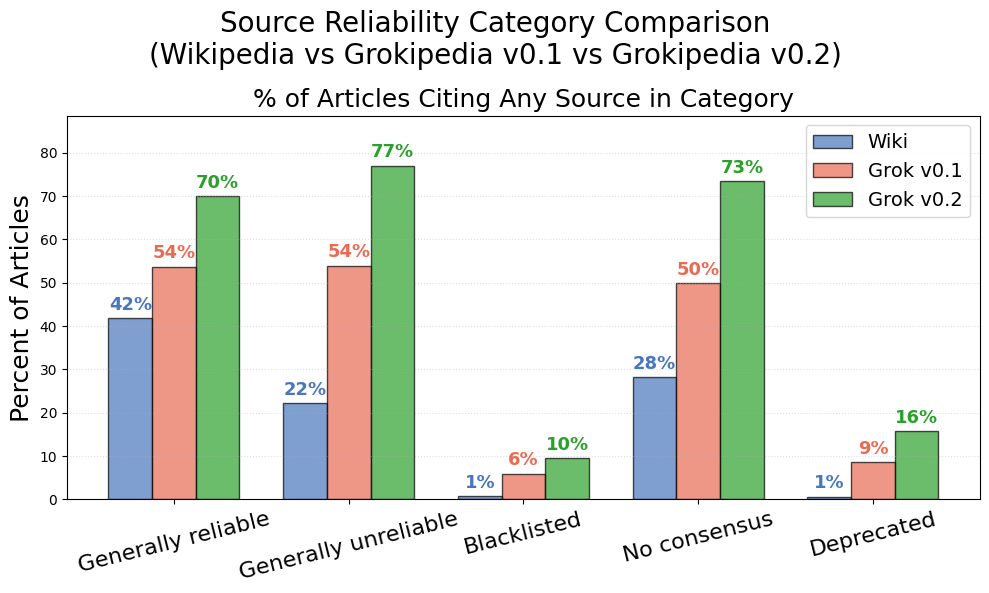

In [21]:
plot_reliability_charts(max_reliability_shift_df, fsuffix='_grok_v0_2', title='Source Reliability Category Comparison\n(Wikipedia vs Grokipedia v0.1 vs Grokipedia v0.2)')

In [6]:
def find_reliability_shift_by_buckets(reliability_df,
                                      grok_v01_idx_path='../results/overall/cached_grok_idx.pkl',
                                      grok_v02_idx_path='../results/v0.2_scrape/cached_grokipedia_idx_v0_2.pkl',
                                      wiki_idx_path='../results/overall/cached_wiki_idx.pkl',
                                      grok_v01_jsonl_path='../grokipedia_scrape.ndjson',
                                      grok_v02_jsonl_path='../results/v0.2_scrape/scraped_data.jsonl',
                                      wiki_jsonl_path='../grokipedia_wikipedia_articles.ndjson'):
    """
    Find articles where reliability shifts occur, grouped by reliability score buckets (0.2-sized buckets).
    Uses reliability_df DataFrame with reliability_score instead of discrete status categories.
    Only processes articles that exist in ALL THREE sources (Wikipedia, Grokipedia v0.1, and v0.2).
    Keyed on v0.2 titles - iterates over v0.2 index and requires matching entries in Wikipedia and v0.1.
    
    Args:
        reliability_df: DataFrame with 'domain' and 'reliability_score' (or 'pc1') columns
        grok_v01_idx_path: Path to cached Grokipedia v0.1 index pickle file
        grok_v02_idx_path: Path to cached Grokipedia v0.2 index pickle file
        wiki_idx_path: Path to cached Wikipedia index pickle file
        grok_v01_jsonl_path: Path to Grokipedia v0.1 scraped data JSONL file
        grok_v02_jsonl_path: Path to Grokipedia v0.2 scraped data JSONL file
        wiki_jsonl_path: Path to Wikipedia articles JSONL file
    
    Returns:
        List of tuples with article shift data grouped by reliability score buckets for all three sources
    """
    import pickle
    from urllib.parse import urlparse
    import re
    import pandas as pd
    
    # Define buckets: 0-0.2, 0.2-0.4, 0.4-0.6, 0.6-0.8, 0.8-1.0
    bucket_size = 0.2
    buckets = [(i * bucket_size, (i + 1) * bucket_size) for i in range(5)]
    bucket_labels = [f"{i * bucket_size:.1f}-{(i + 1) * bucket_size:.1f}" for i in range(5)]
    
    def get_bucket(score):
        """Assign a reliability score to a bucket."""
        if pd.isna(score):
            return None
        for i, (low, high) in enumerate(buckets):
            if low <= score < high:
                return i
        # Handle edge case: score == 1.0
        if score == 1.0:
            return 4
        return None
    
    def stem_domain(domain):
        # Remove common www/amp/mobile etc, keep only base domain
        if domain.startswith("www."):
            domain = domain[4:]
        # Remove mobile/amp subdomains if desired
        domain = re.sub(r"^(m|amp|en|web|mobile)\.", "", domain)
        return domain.lower()
    
    # Load cached indexes
    print("Loading cached indexes...")
    with open(grok_v01_idx_path, 'rb') as f:
        grok_v01_idx = pickle.load(f)
    with open(grok_v02_idx_path, 'rb') as f:
        grok_v02_idx = pickle.load(f)
    with open(wiki_idx_path, 'rb') as f:
        wiki_idx = pickle.load(f)
    
    print(f"  Grokipedia v0.1 index: {len(grok_v01_idx)} entries")
    print(f"  Grokipedia v0.2 index: {len(grok_v02_idx)} entries")
    print(f"  Wikipedia index: {len(wiki_idx)} entries")
    
    # Create lookup dict for reliability score by normalized domain
    # Handle both 'reliability_score' and 'pc1' column names
    score_col = 'reliability_score' if 'reliability_score' in reliability_df.columns else 'pc1'
    reliability_lookup = {}
    for _, row in reliability_df.iterrows():
        domain = row['domain']
        if domain and pd.notna(row.get(score_col)):
            stemmed = stem_domain(domain)
            reliability_lookup[stemmed] = row[score_col]
    
    def get_article_reliability_bucket_counts_from_page(page_obj, is_grok=True):
        """Extract references from a page object and count by reliability score bucket."""
        # Initialize counts for each bucket
        bucket_counts = {i: 0 for i in range(5)}
        other_count = 0
        total_count = 0
        
        if is_grok:
            # Grokipedia structure: data['references'] with link['href']
            refs = page_obj.get('data', {}).get('references', [])
            for ref in refs:
                link = ref.get('link') if isinstance(ref, dict) else None
                href = link.get('href') if (link and isinstance(link, dict)) else None
                if href:
                    domain = urlparse(href).netloc
                    if domain:
                        stemmed = stem_domain(domain)
                        total_count += 1
                        if stemmed in reliability_lookup:
                            score = reliability_lookup[stemmed]
                            bucket_idx = get_bucket(score)
                            if bucket_idx is not None:
                                bucket_counts[bucket_idx] += 1
                            else:
                                other_count += 1
                        else:
                            other_count += 1
        else:
            # Wikipedia structure: references with metadata['url']
            refs = page_obj.get('references', [])
            for ref in refs:
                metadata = ref.get('metadata') if isinstance(ref, dict) else None
                url = metadata.get('url') if (metadata and isinstance(metadata, dict)) else None
                if url:
                    domain = urlparse(url).netloc
                    if domain:
                        stemmed = stem_domain(domain)
                        total_count += 1
                        if stemmed in reliability_lookup:
                            score = reliability_lookup[stemmed]
                            bucket_idx = get_bucket(score)
                            if bucket_idx is not None:
                                bucket_counts[bucket_idx] += 1
                            else:
                                other_count += 1
                        else:
                            other_count += 1
        
        return (bucket_counts[0], bucket_counts[1], bucket_counts[2], bucket_counts[3], bucket_counts[4], other_count, total_count)
    
    # Process all articles in Grokipedia v0.2 index that also exist in Wikipedia and v0.1
    print("Processing articles (intersection of all three sources, keyed on v0.2)...")
    article_bucket_shifts = []
    processed = 0
    skipped = 0
    
    for norm_title, grok_v02_info in grok_v02_idx.items():
        # Check if article exists in all three sources
        wiki_offset = wiki_idx.get(norm_title)
        grok_v01_offset = grok_v01_idx.get(norm_title)
        
        # Skip if not in all three sources
        if wiki_offset is None or grok_v01_offset is None:
            skipped += 1
            continue
        
        # Load Grokipedia v0.2 page
        if isinstance(grok_v02_info, tuple):
            # Grok index stores (filename, offset)
            grok_v02_file, grok_v02_offset = grok_v02_info
        else:
            # Fallback: assume it's just an offset
            grok_v02_file = grok_v02_jsonl_path
            grok_v02_offset = grok_v02_info
        
        try:
            grok_v02_page = get_object_at_offset(grok_v02_file, grok_v02_offset)
            grok_v01_page = get_object_at_offset(grok_v01_jsonl_path, grok_v01_offset)
            wiki_page = get_object_at_offset(wiki_jsonl_path, wiki_offset)
        except Exception as e:
            skipped += 1
            continue
        
        # Get article title from v0.2 page
        article_title = grok_v02_page.get('data', {}).get('main_title', norm_title)
        if not article_title:
            article_title = norm_title
        
        # Get reliability bucket counts from all three sources
        wp_b0, wp_b1, wp_b2, wp_b3, wp_b4, wp_other, wp_total = \
            get_article_reliability_bucket_counts_from_page(wiki_page, is_grok=False)
        grok_v01_b0, grok_v01_b1, grok_v01_b2, grok_v01_b3, grok_v01_b4, grok_v01_other, grok_v01_total = \
            get_article_reliability_bucket_counts_from_page(grok_v01_page, is_grok=True)
        grok_v02_b0, grok_v02_b1, grok_v02_b2, grok_v02_b3, grok_v02_b4, grok_v02_other, grok_v02_total = \
            get_article_reliability_bucket_counts_from_page(grok_v02_page, is_grok=True)
        
        # Calculate shifts for each bucket: WP_count - Grok_count (using v0.2, not v0.1)
        # Positive means WP has more, negative means Grok has more
        shifts = [
            wp_b0 - grok_v02_b0,
            wp_b1 - grok_v02_b1,
            wp_b2 - grok_v02_b2,
            wp_b3 - grok_v02_b3,
            wp_b4 - grok_v02_b4
        ]
        
        # Calculate overall shift metric: weighted sum (higher buckets weighted more)
        # This gives more weight to shifts in higher reliability buckets
        weighted_shift = sum(shifts[i] * (i + 1) for i in range(5))
        
        article_bucket_shifts.append((
            article_title,
            # Wikipedia buckets
            wp_b0, wp_b1, wp_b2, wp_b3, wp_b4, wp_other, wp_total,
            # Grokipedia v0.1 buckets
            grok_v01_b0, grok_v01_b1, grok_v01_b2, grok_v01_b3, grok_v01_b4, grok_v01_other, grok_v01_total,
            # Grokipedia v0.2 buckets
            grok_v02_b0, grok_v02_b1, grok_v02_b2, grok_v02_b3, grok_v02_b4, grok_v02_other, grok_v02_total,
            # Individual bucket shifts (WP - Grok v0.2)
            shifts[0], shifts[1], shifts[2], shifts[3], shifts[4],
            # Overall weighted shift
            weighted_shift
        ))
        
        processed += 1
        if processed % 1000 == 0:
            print(f"  Processed {processed} articles...")
    
    print(f"\nProcessed {processed} articles, skipped {skipped} articles")
    print(f"Returning {len(article_bucket_shifts)} results")
    
    return article_bucket_shifts

bucket_columns = [
    'title',
    # Wikipedia buckets
    'wp_bucket_0_0.2', 'wp_bucket_0.2_0.4', 'wp_bucket_0.4_0.6', 'wp_bucket_0.6_0.8', 'wp_bucket_0.8_1.0', 'wp_other', 'wp_total',
    # Grokipedia v0.1 buckets
    'grok_v01_bucket_0_0.2', 'grok_v01_bucket_0.2_0.4', 'grok_v01_bucket_0.4_0.6', 'grok_v01_bucket_0.6_0.8', 'grok_v01_bucket_0.8_1.0', 'grok_v01_other', 'grok_v01_total',
    # Grokipedia v0.2 buckets
    'grok_v02_bucket_0_0.2', 'grok_v02_bucket_0.2_0.4', 'grok_v02_bucket_0.4_0.6', 'grok_v02_bucket_0.6_0.8', 'grok_v02_bucket_0.8_1.0', 'grok_v02_other', 'grok_v02_total',
    # Individual bucket shifts (WP - Grok v0.2)
    'shift_bucket_0_0.2', 'shift_bucket_0.2_0.4', 'shift_bucket_0.4_0.6', 'shift_bucket_0.6_0.8', 'shift_bucket_0.8_1.0',
    # Overall weighted shift
    'weighted_shift'
]

In [7]:
lin_reliability = pd.read_csv(f'../supplemental_data/news_reliability/LinRating_Join.csv')
lin_reliability['reliability_score'] = lin_reliability['pc1']

article_maximals_lin = find_reliability_shift_by_buckets(lin_reliability)
max_reliability_shift_df_lin = pd.DataFrame(article_maximals_lin, columns=bucket_columns)

Loading cached indexes...
  Grokipedia v0.1 index: 880623 entries
  Grokipedia v0.2 index: 48289 entries
  Wikipedia index: 857392 entries
Processing articles (intersection of all three sources, keyed on v0.2)...
  Processed 1000 articles...
  Processed 2000 articles...
  Processed 3000 articles...
  Processed 4000 articles...
  Processed 5000 articles...
  Processed 6000 articles...
  Processed 7000 articles...
  Processed 8000 articles...
  Processed 9000 articles...
  Processed 10000 articles...
  Processed 11000 articles...
  Processed 12000 articles...
  Processed 13000 articles...
  Processed 14000 articles...
  Processed 15000 articles...
  Processed 16000 articles...
  Processed 17000 articles...
  Processed 18000 articles...
  Processed 19000 articles...
  Processed 20000 articles...
  Processed 21000 articles...
  Processed 22000 articles...
  Processed 23000 articles...
  Processed 24000 articles...
  Processed 25000 articles...
  Processed 26000 articles...
  Processed 2700

In [24]:
def plot_reliability_bucket_charts(filtered_df, fsuffix='', show=True, title=None):
    """
    Plots a bar chart showing the percentage of articles containing at least one source
    in each reliability score bucket for three sources: Wikipedia, Grokipedia v0.1, and Grokipedia v0.2.

    Parameters:
        filtered_df (pd.DataFrame): DataFrame with bucket columns (from find_reliability_shift_by_buckets)
        fsuffix (str): Suffix for output filename
        show (bool): If True, calls plt.show() at end.
        title (str): Optional custom title for the figure. If None, uses default title.
    """

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch
    import matplotlib.colors as mcolors

    # --- Setup buckets, labels, colors ---
    bucket_labels = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0', 'other']
    display_names = {
        '0.0-0.2': '0.0-0.2',
        '0.2-0.4': '0.2-0.4',
        '0.4-0.6': '0.4-0.6',
        '0.6-0.8': '0.6-0.8',
        '0.8-1.0': '0.8-1.0',
        'other': 'No score'
    }
    
    # Create color map for possible legend
    from matplotlib.colors import to_hex, LinearSegmentedColormap
    spect_cmap = LinearSegmentedColormap.from_list(
        "green_yellow_red", [(0.0, "#D73027"), (0.5, "#FEE08B"), (1.0, "#1A9850")]  # red, yellow, green
    )
    bucket_midpoints = {
        '0.0-0.2': 0.1,
        '0.2-0.4': 0.3,
        '0.4-0.6': 0.5,
        '0.6-0.8': 0.7,
        '0.8-1.0': 0.9,
    }
    color_map = {}
    for bucket_label in bucket_labels:
        if bucket_label == 'other':
            color_map[bucket_label] = 'grey'
        else:
            midpoint = bucket_midpoints[bucket_label]
            color_map[bucket_label] = to_hex(spect_cmap(midpoint))

    # --- Data prep ---
    bucket_to_col = {
        '0.0-0.2': '0_0.2',
        '0.2-0.4': '0.2_0.4',
        '0.4-0.6': '0.4_0.6',
        '0.6-0.8': '0.6_0.8',
        '0.8-1.0': '0.8_1.0'
    }
    sources = ['Wiki', 'Grok v0.1', 'Grok v0.2']
    source_prefixes = ['wp', 'grok_v01', 'grok_v02']

    main_buckets = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
    bucket_display_labels = [display_names[b] for b in main_buckets]
    bar_x = np.arange(len(main_buckets))
    bar_width = 0.25

    n_articles = len(filtered_df)
    percentages = {source: [] for source in sources}
    
    # Print the number of articles containing at least one 0-0.2-reliability citation
    wp_0_0_2_col = 'wp_bucket_0_0.2'
    grok_v01_0_0_2_col = 'grok_v01_bucket_0_0.2'
    grok_v02_0_0_2_col = 'grok_v02_bucket_0_0.2'
    wp_0_0_2_num = (filtered_df[wp_0_0_2_col] > 0).sum() if wp_0_0_2_col in filtered_df.columns else 0
    grok_v01_0_0_2_num = (filtered_df[grok_v01_0_0_2_col] > 0).sum() if grok_v01_0_0_2_col in filtered_df.columns else 0
    grok_v02_0_0_2_num = (filtered_df[grok_v02_0_0_2_col] > 0).sum() if grok_v02_0_0_2_col in filtered_df.columns else 0

    print(f"Number of articles with at least one 0-0.2 source: Wikipedia: {wp_0_0_2_num}, Grokipedia v0.1: {grok_v01_0_0_2_num}, Grokipedia v0.2: {grok_v02_0_0_2_num}")
    print(f"Number of pages with a 0-0.2 source in Wikipedia: {wp_0_0_2_num}")
    print(f"Number of pages with a 0-0.2 source in Grokipedia v0.1: {grok_v01_0_0_2_num}")
    print(f"Number of pages with a 0-0.2 source in Grokipedia v0.2: {grok_v02_0_0_2_num}")

    for bucket_label in main_buckets:
        col_suffix = bucket_to_col[bucket_label]
        for i, prefix in enumerate(source_prefixes):
            col = f'{prefix}_bucket_{col_suffix}'
            if col in filtered_df.columns:
                count = (filtered_df[col] > 0).sum()
                percentages[sources[i]].append(count / n_articles * 100)
            else:
                percentages[sources[i]].append(0)

    # --- Plot ---
    fig, ax2 = plt.subplots(1, 1, figsize=(10, 6))
    colors = ["#4977bc", "#e86b54", "#2ca02c"]  # Blue, Red, Green
    for i, source in enumerate(sources):
        offset = (i - 1) * bar_width
        ax2.bar(bar_x + offset, percentages[source], bar_width,
               label=source, color=colors[i], edgecolor='black', alpha=0.7)
        # Add percentage labels
        for j, pct in enumerate(percentages[source]):
            ax2.text(j + offset, pct + 1, f"{pct:.0f}%", ha='center', va='bottom', 
                    fontsize=13, color=colors[i], weight='bold')  # was 11

    ax2.set_xticks(bar_x)
    ax2.set_xticklabels(bucket_display_labels, rotation=14, fontsize=16)  # was 14
    ax2.set_ylim(0, max(max(p) for p in percentages.values()) * 1.15 if percentages else 105)
    ax2.set_ylabel("Percent of Articles", fontsize=18)  # was 16
    ax2.set_title("% of Articles Citing Any Source in Reliability Bucket", fontsize=18)  # was 16
    ax2.legend(loc='upper left', fontsize=14)  # was 12
    ax2.grid(axis='y', linestyle=':', alpha=0.4)

    plot_title = title if title is not None else "% of Articles Citing Any Source in Reliability Bucket"
    fig.suptitle(plot_title, fontsize=20, y=0.98)  # was 18

    fig.tight_layout()
    fig.savefig(f'../graphics/overall_grok_wp_cite_composition_lin_{fsuffix}_just_bars.pdf')

    if show:
        plt.show()

Number of articles with at least one 0-0.2 source: Wikipedia: 45, Grokipedia v0.1: 268, Grokipedia v0.2: 312
Number of pages with a 0-0.2 source in Wikipedia: 45
Number of pages with a 0-0.2 source in Grokipedia v0.1: 268
Number of pages with a 0-0.2 source in Grokipedia v0.2: 312


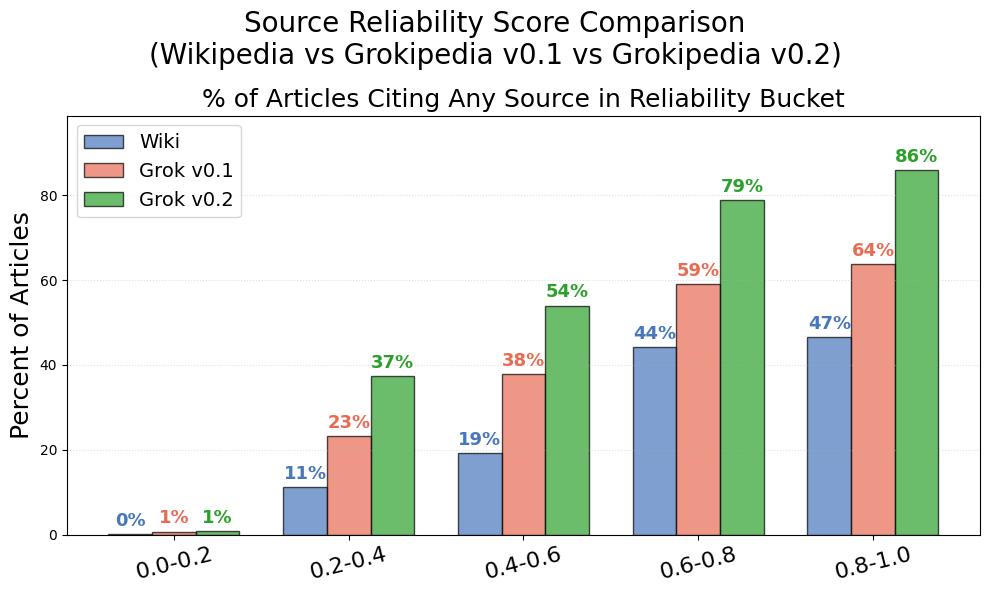

In [25]:
plot_reliability_bucket_charts(max_reliability_shift_df_lin, fsuffix='_grok_v0_2', title='Source Reliability Score Comparison\n(Wikipedia vs Grokipedia v0.1 vs Grokipedia v0.2)')

In [59]:
massacre_leaf_pages = get_leaf_pages_ethnicity('Category:Massacres', filter_='massacre')

Fetched 27 pages
Fetched 10 pages
Fetched 21 pages
Fetched 27 pages
Fetched 4 pages
Fetched 9 pages
Fetched 4 pages
Fetched 23 pages
Fetched 7 pages
Fetched 8 pages
Fetched 3 pages
Fetched 3 pages
Fetched 8 pages
Fetched 20 pages
Fetched 9 pages
Fetched 6 pages
Fetched 5 pages
Fetched 5 pages
Fetched 18 pages
Fetched 20 pages
Fetched 13 pages
Fetched 12 pages
Fetched 9 pages
Fetched 15 pages
Fetched 42 pages
Fetched 15 pages
Fetched 20 pages
Fetched 14 pages
Fetched 19 pages
Fetched 5 pages
Fetched 6 pages
Fetched 10 pages
Fetched 12 pages
Fetched 22 pages
Fetched 6 pages
Fetched 3 pages
Fetched 7 pages
Fetched 4 pages
Fetched 5 pages
Fetched 4 pages
Fetched 136 pages
Fetched 12 pages
Fetched 30 pages
Fetched 19 pages
Fetched 14 pages
Fetched 9 pages
Fetched 27 pages
Fetched 19 pages
Fetched 26 pages
Fetched 14 pages
Fetched 7 pages
Fetched 4 pages
Fetched 30 pages
Fetched 10 pages
Fetched 38 pages
Fetched 28 pages
Fetched 13 pages
Fetched 21 pages
Fetched 27 pages
Fetched 17 pages
Fet

KeyboardInterrupt: 

In [61]:
len(massacre_leaf_pages)

338368